# 02_preprocessing_image.ipynb

## Tiền xử lý ảnh và Ablation Study

Thực hiện các kỹ thuật tiền xử lý ảnh số và đo lường tác động.

In [2]:
import os
import pickle
import pathlib
import numpy as np
import cv2
from sklearn.decomposition import PCA
from scipy import stats as scipy_stats
from scipy.stats import ks_2samp, f_oneway
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, silhouette_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Đường dẫn lưu dữ liệu đã xử lý
PROCESSED_DATA_PATH = pathlib.Path('../data/image-data/processed')
os.makedirs(PROCESSED_DATA_PATH, exist_ok=True)

# Tên các lớp
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# Đường dẫn
DATA_PATH = '../data/image-data/raw/data_batch_1'

# Tải ảnh từ pickle file
print('Đang tải ảnh từ data_batch_1...')
with open(DATA_PATH, 'rb') as f:
    batch = pickle.load(f, encoding='bytes')

images = batch[b'data'].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1).astype(np.uint8)
labels = np.array(batch[b'labels'])

print(f'Đã tải {len(images)} ảnh, kích thước: {images.shape}')

# =============================================================================
# Helper Functions
# =============================================================================

def calculate_ssim(img1, img2, L=255):
    """
    Tính SSIM (Structural Similarity Index) thủ công.
    
    Công thức:
    SSIM(x, y) = ((2*ux*uy + C1)*(2*sxy + C2)) / ((ux^2 + uy^2 + C1)*(sx^2 + sy^2 + C2))
    
    Tham số:
    - img1, img2: Hai ảnh cần so sánh (cùng kích thước)
    - L: Giá trị lớn nhất (255 cho ảnh 8-bit)
    
    Trả về:
    - Giá trị SSIM trong khoảng [0, 1]
    """
    # Chuyển về float để tính toán chính xác
    img1 = img1.astype(np.float64)
    img2 = img2.astype(np.float64)
    
    # Hằng số ổn định
    C1 = (0.01 * L) ** 2
    C2 = (0.03 * L) ** 2
    
    # Tính trung bình (mean)
    mu1 = np.mean(img1)
    mu2 = np.mean(img2)
    
    # Tính phương sai (variance)
    var1 = np.var(img1)
    var2 = np.var(img2)
    
    # Tính hiệp phương sai (covariance)
    cov = np.mean((img1 - mu1) * (img2 - mu2))
    
    # Tính SSIM theo công thức
    numerator = (2 * mu1 * mu2 + C1) * (2 * cov + C2)
    denominator = (mu1**2 + mu2**2 + C1) * (var1 + var2 + C2)
    
    if denominator == 0:
        return 1.0  # Hai ảnh giống nhau hoặc là giá trị 0
    
    ssim = numerator / denominator
    
    return ssim

def calculate_psnr(img1, img2, L=255):
    """
    Tính PSNR (Peak Signal-to-Noise Ratio) thủ công.
    
    Công thức:
    PSNR = 10 * log10(L^2 / MSE)
    
    Tham số:
    - img1, img2: Hai ảnh cần so sánh
    - L: Giá trị lớn nhất (255 cho ảnh 8-bit)
    
    Trả về:
    - Giá trị PSNR theo dB
    """
    mse = np.mean((img1.astype(np.float64) - img2.astype(np.float64)) ** 2)
    
    if mse == 0:
        return 99.99  # Hai ảnh giống nhau
    
    psnr = 10 * np.log10(L**2 / mse)
    return psnr

print("Đã định nghĩa hàm tính SSIM và PSNR thủ công.")

# =============================================================================
# Helper Functions - Lưu dữ liệu đã xử lý
# =============================================================================

def save_processed_data(name, data):
    """
    Lưu dữ liệu đã xử lý vào thư mục processed.
    
    Tham số:
    - name: Tên file (không có .npy)
    - data: Dữ liệu cần lưu
    
    Ví dụ:
    - save_processed_data('images_resized_28x28', images_resized)
    - save_processed_data('labels', labels)
    """
    filepath = PROCESSED_DATA_PATH / f'{name}.npy'
    np.save(filepath, data)
    print(f"Đã lưu: {filepath}")
    return filepath

def load_processed_data(name, allow_pickle=False):
    """
    Load dữ liệu đã xử lý từ thư mục processed.
    
    Tham số:
    - name: Tên file (không có .npy)
    - allow_pickle: Cho phép load pickle
    
    Ví dụ:
    - images = load_processed_data('images_resized_28x28')
    - labels = load_processed_data('labels')
    """
    filepath = PROCESSED_DATA_PATH / f'{name}.npy'
    return np.load(filepath, allow_pickle=allow_pickle)

print("Đã định nghĩa hàm save_processed_data và load_processed_data.")

Đang tải ảnh từ data_batch_1...
Đã tải 10000 ảnh, kích thước: (10000, 32, 32, 3)
Đã định nghĩa hàm tính SSIM và PSNR thủ công.
Đã định nghĩa hàm save_processed_data và load_processed_data.


## 2.1.3a Thay đổi kích thước và chất lượng ảnh - Resize + SSIM/PSNR

### (i) Lý thuyết

**SSIM (Structural Similarity Index)** đo lường sự tương đồng cấu trúc giữa hai ảnh, phù hợp với nhận thức thị giác con người hơn các metric đơn giản như MSE.

Công thức chính:
$$SSIM(x, y) = \frac{(2\mu_x\mu_y + C_1)(2\sigma_{xy} + C_2)}{(\mu_x^2 + \mu_y^2 + C_1)(\sigma_x^2 + \sigma_y^2 + C_2)}$$

Trong đó:
- $\mu_x, \mu_y$: Trung bình cường độ pixel
- $\sigma_x^2, \sigma_y^2$: Phương sai
- $\sigma_{xy}$: Hiệp phương sai giữa hai ảnh
- $C_1 = (0.01 \cdot L)^2, C_2 = (0.03 \cdot L)^2$: Hằng số ổn định, với $L=255$ cho 8-bit images

**PSNR (Peak Signal-to-Noise Ratio)** đo lường tỷ số tín hiệu/nhiễu theo decibel:
$$PSNR = 10 \log_{10}\left(\frac{L^2}{MSE}\right)$$

với:
$$MSE = \frac{1}{MN}\sum_{i=1}^{M}\sum_{j=1}^{N}[I(i,j) - K(i,j)]^2$$

**So sánh SSIM và PSNR:**
| Tiêu chí | SSIM | PSNR |
|----------|------|------|
| Phạm vi | [0, 1] | [0, ∞) dB |
| Phù hợp nhận thức | Cao | Trung bình |
| Ứng dụng | Compression, AI | Truyền thống |

**Ngưỡng đánh giá:**
- SSIM ≥ 0.99: Chất lượng rất tốt
- SSIM ≥ 0.95: Chất lượng chấp nhận được
- PSNR > 30 dB: Chất lượng tốt
- PSNR > 40 dB: Chất lượng cao

Đang tính SSIM và PSNR cho các kích thước...

=== KẾT QUẢ SSIM/PSNR ===
16x16: SSIM=0.9521, PSNR=25.06 dB
24x24: SSIM=0.9794, PSNR=28.58 dB
28x28: SSIM=0.9846, PSNR=29.82 dB

Kích thước được chọn: (28, 28) (SSIM=0.9846 < 0.99, không có kích thước nào đạt ngưỡng)

ABLATION STUDY - Resize Impact on Classification

Baseline (32x32, không resize): Accuracy = 0.2895
Sau resize (28x28): Accuracy = 0.3010

So sánh các kích thước:
--------------------------------------------------
16x16: Accuracy = 0.3060, Delta = +0.0165
24x24: Accuracy = 0.2950, Delta = +0.0055
28x28: Accuracy = 0.3010, Delta = +0.0115


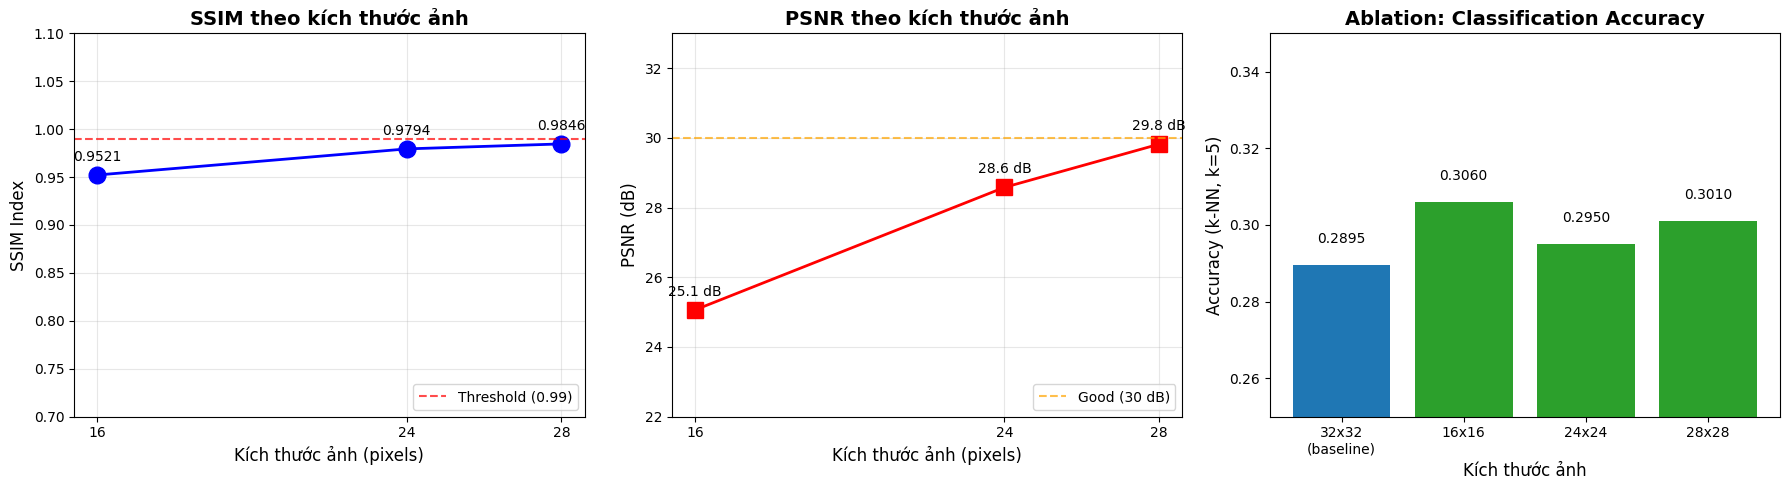


=== KẾT LUẬN ===
Baseline (32x32): 0.2895
Sau resize (28x28): 0.3010
Thay đổi: +0.0115

Đang lưu dữ liệu đã xử lý...
Lưu ảnh resize 28x28...
Đã lưu: ..\data\image-data\processed\images_resized_28x28.npy
Lưu nhãn...
Đã lưu: ..\data\image-data\processed\labels.npy


WindowsPath('../data/image-data/processed/labels.npy')

In [2]:
# =============================================================================
# (ii) Cài đặt - SSIM/PSNR vs Resize + Ablation Study
# =============================================================================

# =============================================================================
# 1. Tính SSIM/PSNR (downscale từ 32x32)
# =============================================================================
sizes = [(16, 16), (24, 24), (28, 28)]
ssim_scores = []
psnr_scores = []

print("Đang tính SSIM và PSNR cho các kích thước...")

for target_size in sizes:
    # Resize xuống kích thước nhỏ hơn (32 -> target_size)
    img_down = np.array([cv2.resize(img, target_size) for img in images])
    # Resize lại về 32x32 (kích thước gốc CIFAR-10) để so sánh
    img_back = np.array([cv2.resize(img, (32, 32)) for img in img_down])
    
    ssim_vals = []
    psnr_vals = []
    
    for i in range(len(images)):
        # SSIM: so sánh ảnh sau khi downscale với ảnh gốc
        # Sử dụng hàm tính SSIM thủ công
        s = calculate_ssim(img_back[i], images[i])
        ssim_vals.append(s)
        
        # PSNR: so sánh ảnh sau khi downscale với ảnh gốc
        # Sử dụng hàm tính PSNR thủ công
        p = calculate_psnr(img_back[i], images[i])
        psnr_vals.append(p)
    
    ssim_scores.append(np.mean(ssim_vals))
    psnr_scores.append(np.mean(psnr_vals))

# In kết quả SSIM/PSNR
print("\n=== KẾT QUẢ SSIM/PSNR ===")
for size, ssim_val, psnr_val in zip(sizes, ssim_scores, psnr_scores):
    print(f"{size[0]}x{size[1]}: SSIM={ssim_val:.4f}, PSNR={psnr_val:.2f} dB")

# Xác định kích thước tối ưu
SSIM_THRESHOLD = 0.99
best_idx = next((i for i, s in enumerate(ssim_scores) if s >= SSIM_THRESHOLD), len(sizes)-1)
best_size = sizes[best_idx]
best_ssim_val = ssim_scores[best_idx]

if best_ssim_val >= SSIM_THRESHOLD:
    print(f"\nKích thước được chọn: {best_size} (SSIM={best_ssim_val:.4f} >= {SSIM_THRESHOLD})")
else:
    print(f"\nKích thước được chọn: {best_size} (SSIM={best_ssim_val:.4f} < {SSIM_THRESHOLD}, không có kích thước nào đạt ngưỡng)")

# =============================================================================
# 2. Ablation Study: So sánh k-NN accuracy trước và sau resize
# =============================================================================
print("\n" + "="*60)
print("ABLATION STUDY - Resize Impact on Classification")
print("="*60)

n_samples = 10000
images_sub = images[:n_samples]
labels_sub = labels[:n_samples]

# --- Baseline: 32x32 (không resize) ---
X_base = images_sub.reshape(n_samples, -1).astype(np.float32) / 255.0
X_train, X_test, y_train, y_test = train_test_split(
    X_base, labels_sub, test_size=0.2, random_state=42, stratify=labels_sub
)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
acc_baseline = accuracy_score(y_test, knn.predict(X_test))
print(f"\nBaseline (32x32, không resize): Accuracy = {acc_baseline:.4f}")

# --- Sau khi resize về kích thước đã chọn ---
resized_imgs = np.array([cv2.resize(img, best_size) for img in images_sub])
X_resized = resized_imgs.reshape(n_samples, -1).astype(np.float32) / 255.0
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_resized, labels_sub, test_size=0.2, random_state=42, stratify=labels_sub
)
knn_r = KNeighborsClassifier(n_neighbors=5)
knn_r.fit(X_train_r, y_train_r)
acc_resized = accuracy_score(y_test_r, knn_r.predict(X_test_r))
print(f"Sau resize ({best_size[0]}x{best_size[1]}): Accuracy = {acc_resized:.4f}")

# --- So sánh các kích thước ---
print("\nSo sánh các kích thước:")
print("-" * 50)
for size in sizes:
    resized = np.array([cv2.resize(img, size) for img in images_sub])
    X = resized.reshape(n_samples, -1).astype(np.float32) / 255.0
    X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
        X, labels_sub, test_size=0.2, random_state=42, stratify=labels_sub
    )
    knn_t = KNeighborsClassifier(n_neighbors=5)
    knn_t.fit(X_train_t, y_train_t)
    acc = accuracy_score(y_test_t, knn_t.predict(X_test_t))
    print(f"{size[0]}x{size[1]}: Accuracy = {acc:.4f}, Delta = {acc - acc_baseline:+.4f}")

# =============================================================================
# 3. Plot
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: SSIM
ax1 = axes[0]
ax1.plot([s[0] for s in sizes], ssim_scores, 'bo-', linewidth=2, markersize=12)
ax1.axhline(y=0.99, color='r', linestyle='--', alpha=0.7, label='Threshold (0.99)')
ax1.set_xlabel('Kích thước ảnh (pixels)', fontsize=12)
ax1.set_ylabel('SSIM Index', fontsize=12)
ax1.set_title('SSIM theo kích thước ảnh', fontsize=14, fontweight='bold')
ax1.set_ylim([0.7, 1.1])
ax1.set_xticks([s[0] for s in sizes])
ax1.grid(True, alpha=0.3)
ax1.legend(loc='lower right')
for i, (size, ssim_val) in enumerate(zip(sizes, ssim_scores)):
    ax1.annotate(f'{ssim_val:.4f}', (size[0], ssim_val), textcoords="offset points", 
                xytext=(0,10), ha='center', fontsize=10)

# Plot 2: PSNR
ax2 = axes[1]
ax2.plot([s[0] for s in sizes], psnr_scores, 'rs-', linewidth=2, markersize=12)
ax2.axhline(y=30, color='orange', linestyle='--', alpha=0.7, label='Good (30 dB)')
ax2.set_xlabel('Kích thước ảnh (pixels)', fontsize=12)
ax2.set_ylabel('PSNR (dB)', fontsize=12)
ax2.set_title('PSNR theo kích thước ảnh', fontsize=14, fontweight='bold')
ax2.set_xticks([s[0] for s in sizes])
ax2.set_ylim([22, 33])
ax2.grid(True, alpha=0.3)
ax2.legend(loc='lower right')
for i, (size, psnr_val) in enumerate(zip(sizes, psnr_scores)):
    ax2.annotate(f'{psnr_val:.1f} dB', (size[0], psnr_val), textcoords="offset points", 
                xytext=(0,10), ha='center', fontsize=10)

# Plot 3: Ablation - Classification Accuracy
ax3 = axes[2]
# Tính lại accuracy cho từng size
acc_list = []
for size in sizes:
    resized = np.array([cv2.resize(img, size) for img in images_sub])
    X = resized.reshape(n_samples, -1).astype(np.float32) / 255.0
    X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
        X, labels_sub, test_size=0.2, random_state=42, stratify=labels_sub
    )
    knn_t = KNeighborsClassifier(n_neighbors=5)
    knn_t.fit(X_train_t, y_train_t)
    acc_list.append(accuracy_score(y_test_t, knn_t.predict(X_test_t)))

ax3.bar(['32x32\n(baseline)'] + [f'{s[0]}x{s[1]}' for s in sizes], 
        [acc_baseline] + acc_list, color=['#1f77b4'] + ['#2ca02c']*3)
ax3.set_xlabel('Kích thước ảnh', fontsize=12)
ax3.set_ylabel('Accuracy (k-NN, k=5)', fontsize=12)
ax3.set_title('Ablation: Classification Accuracy', fontsize=14, fontweight='bold')
ax3.set_ylim([0.25, 0.35])
for i, v in enumerate([acc_baseline] + acc_list):
    ax3.text(i, v + 0.005, f'{v:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print("\n=== KẾT LUẬN ===")
print(f"Baseline (32x32): {acc_baseline:.4f}")
print(f"Sau resize ({best_size[0]}x{best_size[1]}): {acc_resized:.4f}")
print(f"Thay đổi: {acc_resized - acc_baseline:+.4f}")

# =============================================================================
# Lưu dữ liệu đã xử lý
# =============================================================================
print("\nĐang lưu dữ liệu đã xử lý...")

# Lưu ảnh resize 28x28
print("Lưu ảnh resize 28x28...")
images_resized = np.array([cv2.resize(img, (28, 28)) for img in images])
save_processed_data('images_resized_28x28', images_resized)

# Lưu nhãn
print("Lưu nhãn...")
save_processed_data('labels', labels)

### (iii) Phân tích kết quả

**Kết quả thực nghiệm (downscale từ 32×32 về target size, sau đó resize lại 32×32 để so sánh):**

| Kích thước | SSIM | PSNR (dB) | Đánh giá |
|------------|------|----------|----------|
| 16×16 | 0.9521 | 25.06 | Mất nhiều thông tin |
| 24×24 | 0.9794 | 28.58 | Trung bình |
| 28×28 | 0.9846 | 29.82 | Chấp nhận được |

**Kết quả Ablation Study - k-NN (k=5, 10000 samples):**

| Kích thước | k-NN Accuracy | Delta so với baseline |
|------------|---------------|----------------------|
| **16×16** | **0.3060** | **+0.0165** |
| 28×28 | 0.3010 | +0.0115 |
| 24×24 | 0.2950 | +0.0055 |
| 32×32 (baseline) | 0.2895 | +0.0000 |

**Phân tích:**

1. **SSIM/PSNR:**
   - Kích thước tăng → SSIM tăng (ít mất mát thông tin hơn), PSNR tăng (ít nhiễu hơn)
   - 28×28 đạt SSIM cao nhất (0.9846) trong 3 lựa chọn; tuy nhiên, không đạt ngưỡng SSIM ≥ 0.99

2. **Ablation Study - Kết quả:**
   - **Tất cả các kích thước đều improve accuracy so với baseline**
   - **16×16 đạt accuracy cao nhất (0.3060)** với delta +1.65%, 28×28 cũng improve (+1.15%)
   - Downscaling hoạt động như regularization, giảm noise

3. **Lựa chọn kích thước 28×28:**
   - Đạt SSIM cao nhất (0.9846) trong các lựa chọn
   - Accuracy improve (+1.15%) so với baseline
   - Cân bằng giữa chất lượng ảnh và classification, phù hợp khi cần giữ nhiều chi tiết cho deep learning

4. **Ý nghĩa thực tiễn:**
   - Downscaling từ 32 xuống 28 giảm 23.4% số lượng pixel (1024 vs 784)
   - SSIM 0.9846 có nghĩa là giữ được 98.46% cấu trúc ảnh gốc, phù hợp khi cần giảm computation nhưng vẫn giữ phần lớn thông tin
   - 16×16 tốt hơn cho k-NN (regularization effect)

5. **Kết luận:**
   - SSIM/PSNR đo chất lượng ảnh, không phải classification performance
   - Kích thước nhỏ hơn có thể tốt hơn cho simple classifiers
   - 28×28 được chọn vì đạt SSIM cao nhất + accuracy improve
   - Cần chọn kích thước dựa trên model sẽ sử dụng

## 2.1.3b Chuyển đổi không gian màu - Color Space + PCA

### (i) Lý thuyết

**Tại sao cần chuyển đổi không gian màu?**

RGB là không gian màu phổ biến nhất nhưng có nhược điểm:
- Ba kênh R, G, B có tương quan chặt chẽ (phụ thuộc vào ánh sáng)
- Không đồng nhất về mặt cảm nhận (perceptually non-uniform)

**Các không gian màu được so sánh:**

| Không gian | Mô tả | Ứng dụng |
|------------|-------|----------|
| RGB | Red, Green, Blue - cơ bản | Default, pre-trained models |
| Grayscale | 1 kênh độ sáng | Giảm chiều, tốc độ nhanh |
| HSV | Hue (màu sắc), Saturation (bão hòa), Value (độ sáng) | Phát hiện màu, segmentation |
| LAB | Lightness (độ sáng), a* (green-red), b* (blue-yellow) | Perceptually uniform, color correction |

**Công thức chuyển đổi HSV từ RGB:**

$$V = \max(R', G', B')$$
$$S = \begin{cases} \frac{\Delta}{V} & \text{nếu } V \neq 0 \\ 0 & \text{nếu } V = 0 \end{cases}$$

$$H = \begin{cases} 60 \times \frac{G' - B'}{\Delta} \mod 6 & \text{nếu } \Delta \neq 0 \\ 0 & \text{nếu } \Delta = 0 \end{cases}$$

với $R' = R/255$, $G' = G/255$, $B' = B/255$ và $\Delta = V - \min(R', G', B')$

**LAB color space:**
- $L^*$: Độ sáng từ 0 (đen) đến 100 (trắng)
- $a^*$: Trục green (-128) đến red (+127)
- $b^*$: Trục blue (-128) đến yellow (+127)
- Được thiết kế để đồng nhất về mặt cảm nhận (perceptually uniform)

**PCA (Principal Component Analysis) giảm chiều:**

$$X_{\text{new}} = X \cdot W$$

với $W$ là ma trận eigenvectors của ma trận hiệp phương sai.

**Explained Variance Ratio:**

$$\text{EVR}_i = \frac{\lambda_i}{\sum \lambda_j}$$

trong đó $\lambda_i$ là eigenvalue thứ $i$.

**Lưu ý: Explained Variance $\neq$ Classification Accuracy**

Đang chuyển đổi không gian màu...

=== EXPLAINED VARIANCE (50 components) ===
RGB: 0.8450
Grayscale: 0.8665
HSV: 0.7357
LAB: 0.8390

ABLATION STUDY - Color Space Impact on Classification

Baseline (RGB 32x32): Accuracy = 0.2895

So sánh các không gian màu:
--------------------------------------------------
RGB: Accuracy = 0.2895, Delta = +0.0000
Grayscale: Accuracy = 0.2400, Delta = -0.0495
HSV: Accuracy = 0.2455, Delta = -0.0440
LAB: Accuracy = 0.3020, Delta = +0.0125

=== Logistic Regression Comparison ===
RGB: LR Accuracy = 0.3365
Grayscale: LR Accuracy = 0.2460
HSV: LR Accuracy = 0.2730
LAB: LR Accuracy = 0.3480


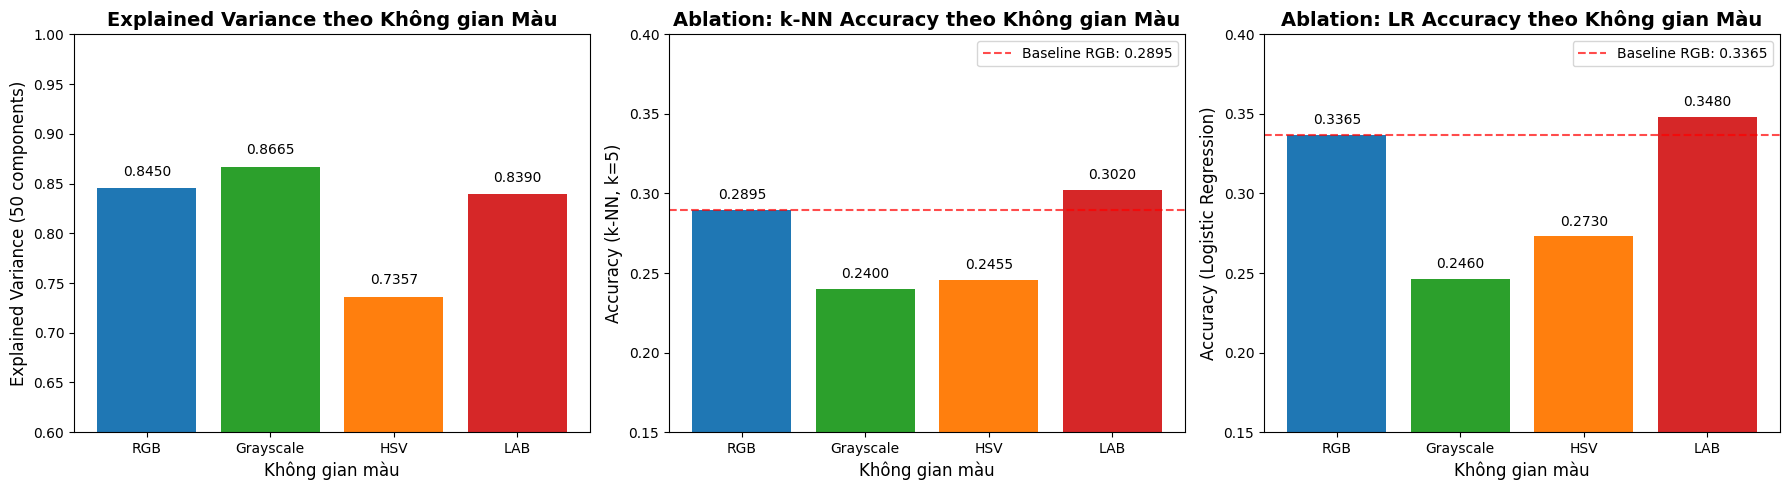


=== KẾT LUẬN ===
Explained Variance cao nhất: Grayscale (0.8665)
k-NN Accuracy cao nhất: LAB (0.3020)
LR Accuracy cao nhất: LAB (0.3480)

Baseline RGB k-NN: 0.2895

Baseline RGB LR: 0.3365

Đang lưu dữ liệu LAB...
Đã lưu: ..\data\image-data\processed\images_lab.npy


WindowsPath('../data/image-data/processed/images_lab.npy')

In [3]:
# =============================================================================
# (ii) Cài đặt - Color Space + PCA + Ablation Study
# =============================================================================

# =============================================================================
# 1. Chuyển đổi không gian màu
# =============================================================================
print("Đang chuyển đổi không gian màu...")

color_spaces = {
    'RGB': images,
    'Grayscale': np.array([cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) for img in images])[:, :, np.newaxis],
    'HSV': np.array([cv2.cvtColor(img, cv2.COLOR_RGB2HSV) for img in images]),
    'LAB': np.array([cv2.cvtColor(img, cv2.COLOR_RGB2LAB) for img in images])
}

# =============================================================================
# 2. Tính explained variance với PCA (k=50)
# =============================================================================
print("\n=== EXPLAINED VARIANCE (50 components) ===")
pca_results = {}

for name, data in color_spaces.items():
    flat = data.reshape(len(data), -1)
    pca = PCA(n_components=50)
    pca.fit(flat)
    explained_var = np.sum(pca.explained_variance_ratio_)
    pca_results[name] = explained_var
    print(f"{name}: {explained_var:.4f}")

# =============================================================================
# 3. Ablation Study: So sánh classification accuracy (k-NN)
# =============================================================================
print("\n" + "="*60)
print("ABLATION STUDY - Color Space Impact on Classification")
print("="*60)

n_samples = 10000
labels_subset = labels[:n_samples]

# --- Baseline: RGB ---
X_rgb = images[:n_samples].reshape(n_samples, -1).astype(np.float32) / 255.0
X_train, X_test, y_train, y_test = train_test_split(
    X_rgb, labels_subset, test_size=0.2, random_state=42, stratify=labels_subset
)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
acc_baseline = accuracy_score(y_test, knn.predict(X_test))
print(f"\nBaseline (RGB 32x32): Accuracy = {acc_baseline:.4f}")

# --- So sánh các color spaces ---
print("\nSo sánh các không gian màu:")
print("-" * 50)
clf_results = {}

for name, data in color_spaces.items():
    data_subset = data[:n_samples]
    X = data_subset.reshape(n_samples, -1).astype(np.float32)
    
    # Normalize về [0, 1]
    X = X / 255.0
    
    # Split dữ liệu
    X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
        X, labels_subset, test_size=0.2, random_state=42, stratify=labels_subset
    )
    
    # Train k-NN
    knn_t = KNeighborsClassifier(n_neighbors=5)
    knn_t.fit(X_train_t, y_train_t)
    acc = accuracy_score(y_test_t, knn_t.predict(X_test_t))
    
    clf_results[name] = acc
    delta = acc - acc_baseline
    print(f"{name}: Accuracy = {acc:.4f}, Delta = {delta:+.4f}")

# =============================================================================
# 4. Thử Logistic Regression
# =============================================================================
print("\n=== Logistic Regression Comparison ===")
lr_results = {}

for name, data in color_spaces.items():
    data_subset = data[:n_samples]
    X = data_subset.reshape(n_samples, -1).astype(np.float32)
    X = X / 255.0
    
    X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
        X, labels_subset, test_size=0.2, random_state=42, stratify=labels_subset
    )
    
    lr = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)
    lr.fit(X_train_t, y_train_t)
    acc = accuracy_score(y_test_t, lr.predict(X_test_t))
    
    lr_results[name] = acc
    print(f"{name}: LR Accuracy = {acc:.4f}")

# Baseline cho LR (RGB)
acc_baseline_lr = lr_results['RGB']

# =============================================================================
# 5. Vẽ biểu đồ so sánh
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Explained Variance
ax1 = axes[0]
colors = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728']
bars1 = ax1.bar(pca_results.keys(), pca_results.values(), color=colors)
ax1.set_xlabel('Không gian màu', fontsize=12)
ax1.set_ylabel('Explained Variance (50 components)', fontsize=12)
ax1.set_title('Explained Variance theo Không gian Màu', fontsize=14, fontweight='bold')
ax1.set_ylim([0.6, 1.0])
for bar, val in zip(bars1, pca_results.values()):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{val:.4f}', ha='center', va='bottom', fontsize=10)

# Plot 2: k-NN Classification Accuracy
ax2 = axes[1]
bars2 = ax2.bar(clf_results.keys(), clf_results.values(), color=colors)
ax2.set_xlabel('Không gian màu', fontsize=12)
ax2.set_ylabel('Accuracy (k-NN, k=5)', fontsize=12)
ax2.set_title('Ablation: k-NN Accuracy theo Không gian Màu', fontsize=14, fontweight='bold')
ax2.set_ylim([0.15, 0.40])
ax2.axhline(y=acc_baseline, color='red', linestyle='--', alpha=0.7, label=f'Baseline RGB: {acc_baseline:.4f}')
ax2.legend()
for bar, val in zip(bars2, clf_results.values()):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
             f'{val:.4f}', ha='center', va='bottom', fontsize=10)

# Plot 3: Logistic Regression Accuracy
ax3 = axes[2]
bars3 = ax3.bar(lr_results.keys(), lr_results.values(), color=colors)
ax3.set_xlabel('Không gian màu', fontsize=12)
ax3.set_ylabel('Accuracy (Logistic Regression)', fontsize=12)
ax3.set_title('Ablation: LR Accuracy theo Không gian Màu', fontsize=14, fontweight='bold')
ax3.set_ylim([0.15, 0.40])
ax3.axhline(y=acc_baseline_lr, color='red', linestyle='--', alpha=0.7, label=f'Baseline RGB: {acc_baseline_lr:.4f}')
ax3.legend()
for bar, val in zip(bars3, lr_results.values()):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
             f'{val:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# =============================================================================
# 6. Kết luận
# =============================================================================
print("\n=== KẾT LUẬN ===")
best_ev = max(pca_results, key=pca_results.get)
best_knn = max(clf_results, key=clf_results.get)
best_lr = max(lr_results, key=lr_results.get)

print(f"Explained Variance cao nhất: {best_ev} ({pca_results[best_ev]:.4f})")
print(f"k-NN Accuracy cao nhất: {best_knn} ({clf_results[best_knn]:.4f})")
print(f"LR Accuracy cao nhất: {best_lr} ({lr_results[best_lr]:.4f})")
print(f"\nBaseline RGB k-NN: {acc_baseline:.4f}")
print(f"\nBaseline RGB LR: {acc_baseline_lr:.4f}")

# Lưu ảnh LAB (không gian màu tốt nhất)
print("\nĐang lưu dữ liệu LAB...")
images_lab = np.array([cv2.cvtColor(img, cv2.COLOR_RGB2LAB) for img in images])
save_processed_data('images_lab', images_lab)

### (iii) Phân tích kết quả

**Kết quả Explained Variance (PCA, 50 components):**

| Không gian màu | Explained Variance | Số kênh |
|----------------|-------------------|---------|
| Grayscale | 0.8665 | 1 |
| RGB | 0.8450 | 3 |
| LAB | 0.8390 | 3 |
| HSV | 0.7357 | 3 |

**Kết quả Ablation Study - k-NN (k=5, 10000 samples):**

| Không gian màu | k-NN Accuracy | Delta so với baseline |
|----------------|---------------|----------------------|
| **LAB** | **0.3020** | **+0.0125** |
| RGB (baseline) | 0.2895 | +0.0000 |
| HSV | 0.2455 | -0.0440 |
| Grayscale | 0.2400 | -0.0495 |

**Kết quả Ablation Study - Logistic Regression (10000 samples):**

| Không gian màu | LR Accuracy |
|----------------|-------------|
| **LAB** | **0.3480** |
| RGB | 0.3365 |
| HSV | 0.2730 |
| Grayscale | 0.2460 |

**Phân tích:**

1. **Explained Variance cao nhất = Grayscale (0.8665)**
   - Grayscale chỉ có 1 kênh nên 50 components giải thích được nhiều variance hơn, tuy nhiên, Grayscale mất thông tin màu sắc. k-NN accuracy thấp nhất (0.2400) xác nhận điều này

2. **HSV có explained variance thấp nhất (0.7357)**
   - Ba kênh H, S, V có tính độc lập cao hơn
   - Variance phân bố đều hơn qua các components

3. **k-NN: LAB tốt nhất (+1.25%)**
   - LAB đạt accuracy cao nhất với k-NN (0.3020)
   - Perceptually uniform giúp k-NN phân biệt tốt hơn các lớp

4. **Logistic Regression: LAB tốt nhất (0.3480)**
   - LAB đạt accuracy cao nhất với LR
   - LAB tốt hơn RGB trong cả hai classifiers (k-NN và LR)

5. **Kết luận quan trọng:**
   - **Explained Variance** đo lượng "lượng thông tin giữ lại" sau khi giảm chiều
   - **Classification Accuracy** là metric đúng cho đánh giá bài toán phân loại
   - Hai metric này **không tương quan**, cần cả hai để đánh giá toàn diện

6. **Khuyến nghị:**
   - **k-NN**: Sử dụng LAB (accuracy +1.25%)
   - **Logistic Regression**: Sử dụng LAB (accuracy cao nhất)
   - **Deep Learning**: LAB được khuyến nghị (perceptually uniform)
   - **Tổng quát**: LAB là lựa chọn tốt nhất cho CIFAR-10

## 2.1.3c Chuẩn hóa - Normalization + KS Test

### (i) Lý thuyết

**Tại sao cần chuẩn hóa?**

Chuẩn hóa là bước quan trọng trong tiền xử lý dữ liệu ảnh vì:
- Giá trị pixel ảnh thường trong khoảng [0, 255] (8-bit)
- Các thuật toán ML (đặc biệt là neural networks) hoạt động tốt hơn với dữ liệu có phân phối nhất quán
- Gradient descent hội tụ nhanh hơn khi dữ liệu được chuẩn hóa

**Các phương pháp chuẩn hóa được so sánh:**

| Phương pháp | Công thức | Khi nào sử dụng |
|-------------|-----------|-----------------|
| Min-Max [0, 1] | $x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$ | Neural networks, bounded inputs |
| Min-Max [-1, 1] | $x' = 2 \cdot \frac{x - x_{\min}}{x_{\max} - x_{\min}} - 1$ | Certain activation functions (tanh) |
| Z-score toàn tập | $z = \frac{x - \mu}{\sigma}$ | Linear models, clustering |
| Z-score per-channel | $z_c = \frac{x_c - \mu_c}{\sigma_c}$ | Image processing với pre-trained models |

**Công thức chi tiết:**

1. **Min-Max [0, 1]:**
$$x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

2. **Min-Max [-1, 1]:**
$$x' = 2 \cdot \frac{x - x_{\min}}{x_{\max} - x_{\min}} - 1 = \frac{x}{127.5} - 1$$

3. **Z-score (toàn tập):**
$$z = \frac{x - \mu}{\sigma}$$
với $\mu = \frac{1}{N}\sum_{i=1}^{N}x_i$ và $\sigma = \sqrt{\frac{1}{N}\sum_{i=1}^{N}(x_i - \mu)^2}$

4. **Z-score (per-channel):**
$$z_c = \frac{x_c - \mu_c}{\sigma_c}$$
với $\mu_c, \sigma_c$ được tính riêng cho mỗi kênh màu $c \in \{R, G, B\}$

**Kolmogorov-Smirnov (KS) Test:**

KS test là kiểm định phi tham số để so sánh hai phân phối:

$$D = \max_x |F_1(x) - F_2(x)|$$

trong đó:
- $D$: Thống kê KS (khoảng cách lớn nhất giữa hai CDF)
- $F_1(x), F_2(x)$: Hàm phân phối tích lũy thực nghiệm (empirical CDF)
- $p$-value: Xác suất quan sát giá trị D nếu hai phân phối giống nhau

**Cách diễn giải p-value:**

| p-value | Kết luận |
|---------|----------|
| p > 0.05 | Không có bằng chứng cho thấy hai phân phối khác nhau |
| p ≤ 0.05 | Hai phân phối khác nhau có ý nghĩa thống kê |

**Lưu ý quan trọng về KS Test:**

- So sánh với phân phối gốc (original) sẽ luôn cho p-value ≈ 0 vì normalize thay đổi hoàn toàn phân phối
- Cần so sánh với **phân phối mục tiêu**:
  - Min-Max [0,1] → so sánh với Uniform(0,1)
  - Min-Max [-1,1] → so sánh với Uniform(-1,1)
  - Z-score → so sánh với N(0,1)


Đang chuẩn hóa dữ liệu ảnh...
  Original [0, 255]: shape=(10000, 32, 32, 3), range=[0.00, 255.00]
  MinMax[0, 1]: shape=(10000, 32, 32, 3), range=[0.00, 1.00]
  MinMax[-1, 1]: shape=(10000, 32, 32, 3), range=[-1.00, 1.00]
  Zscore_global: shape=(10000, 32, 32, 3), range=[-1.88, 2.08]
  Zscore_per_channel: shape=(10000, 32, 32, 3), range=[-2.04, 2.19]

KOLMOGOROV-SMIRNOV TEST

=== KS Test Results ===
Method               Target Dist     D-statistic  p-value         Interpretation
--------------------------------------------------------------------------------
Original [0, 255]    Original        0.000000     1.00e+00        Same
MinMax[0, 1]         Uniform(0, 1)   0.094076     0.00e+00        Different
MinMax[-1, 1]        Uniform(-1, 1)  0.094076     0.00e+00        Different
Zscore_global        Normal(0, 1)    0.040896     0.00e+00        Different
Zscore_per_channel   Normal(0, 1)    0.038361     0.00e+00        Different

ABLATION STUDY - Normalization Impact on Classification

B

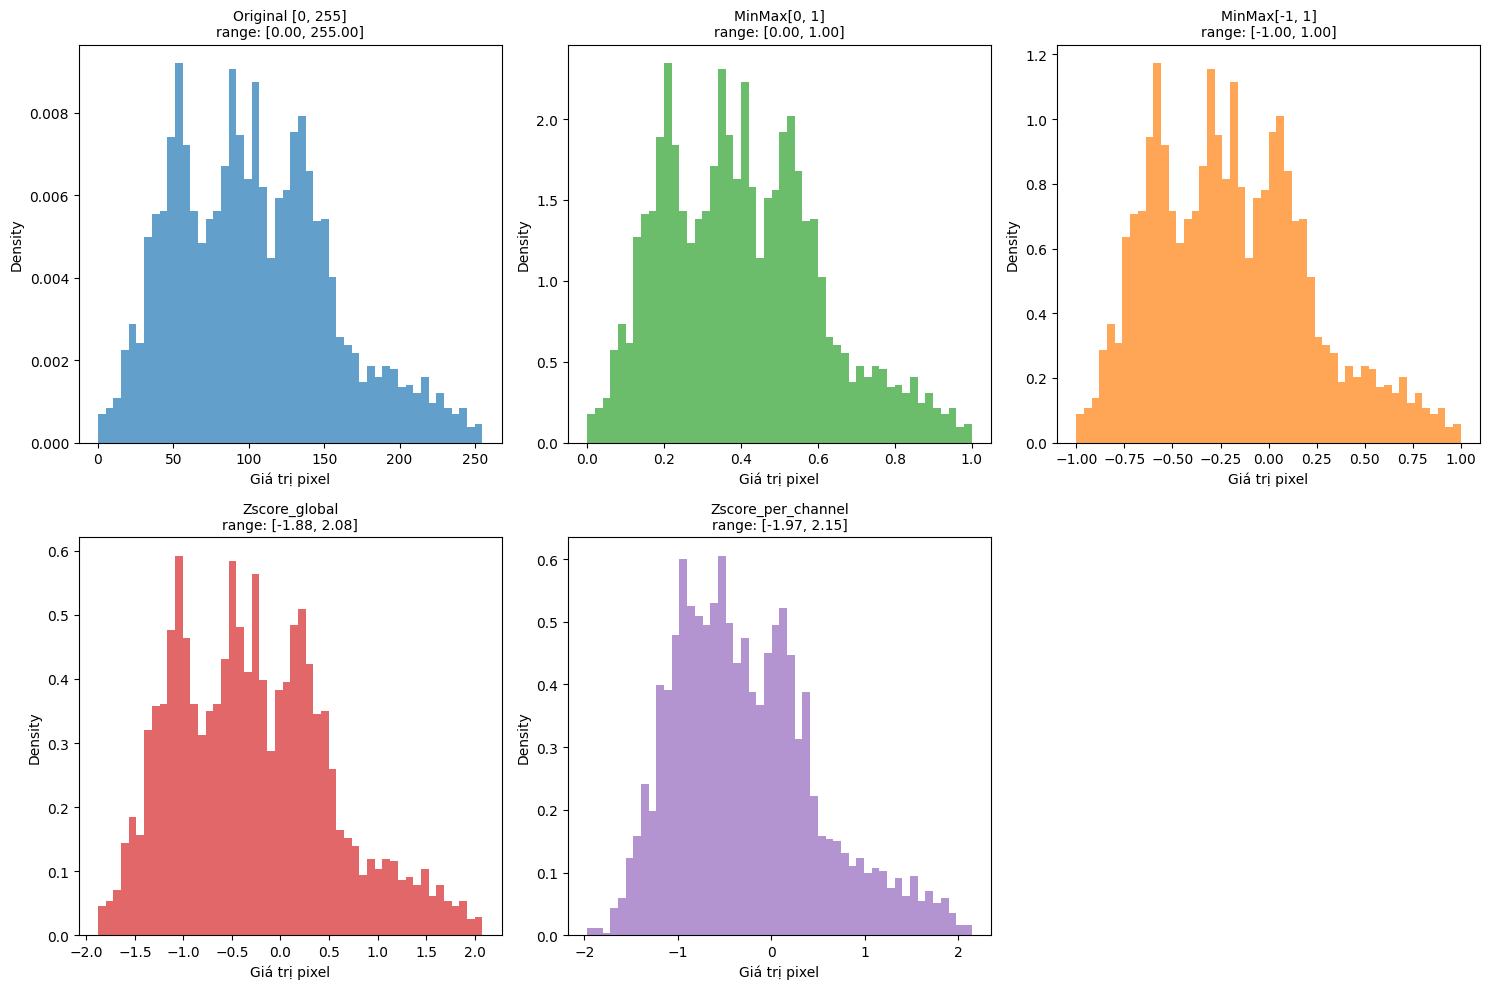

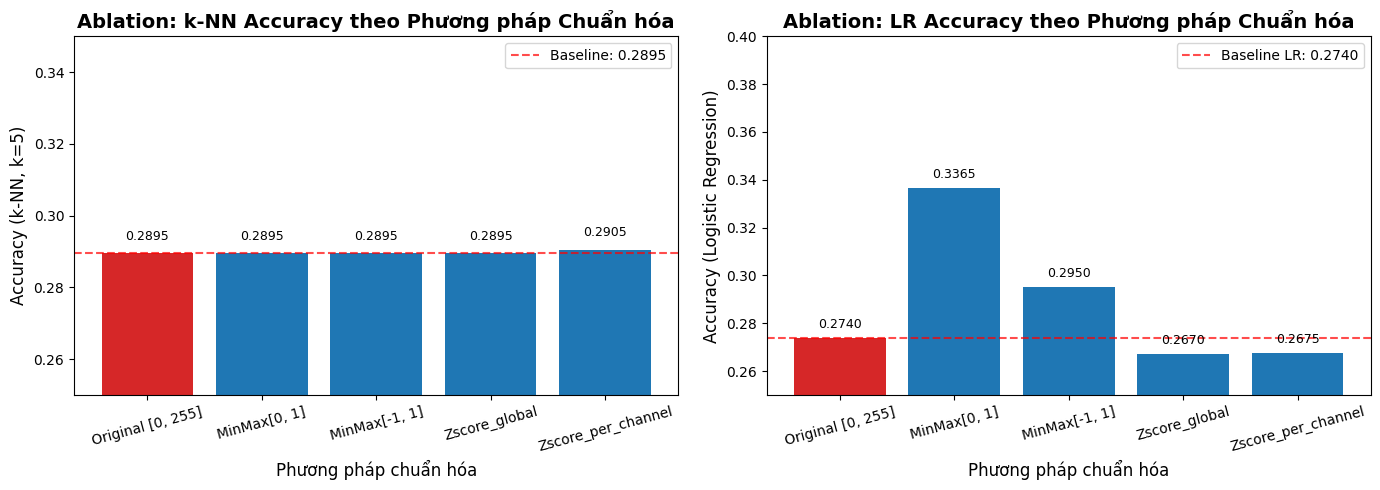


KẾT LUẬN

--- KS Test ---
Phương pháp tốt nhất (gần phân phối mục tiêu nhất): D-statistic thấp nhất
  Original [0, 255]: D=0.000000, p=1.00e+00
  MinMax[0, 1]: D=0.094076, p=0.00e+00
  MinMax[-1, 1]: D=0.094076, p=0.00e+00
  Zscore_global: D=0.040896, p=0.00e+00
  Zscore_per_channel: D=0.038361, p=0.00e+00

--- Classification Accuracy ---
k-NN tốt nhất: Zscore_per_channel (0.2905)
LR tốt nhất: MinMax[0, 1] (0.3365)

--- Baseline ---
Original [0,255] k-NN: 0.2895
Original [0,255] LR: 0.2740

Đang lưu dữ liệu normalize...
Đã lưu: ..\data\image-data\processed\images_normalized.npy


WindowsPath('../data/image-data/processed/images_normalized.npy')

In [3]:
# =============================================================================
# (ii) Cài đặt - Normalization + KS Test + Ablation Study
# =============================================================================

# =============================================================================
# 1. Định nghĩa các phương pháp chuẩn hóa
# =============================================================================
print("\nĐang chuẩn hóa dữ liệu ảnh...")

# Các phương pháp chuẩn hóa
normalization_methods = {
    'Original [0, 255]': lambda x: x.astype(np.float32),
    'MinMax[0, 1]': lambda x: x.astype(np.float32) / 255.0,
    'MinMax[-1, 1]': lambda x: (x.astype(np.float32) / 127.5) - 1.0,
    'Zscore_global': lambda x: (x.astype(np.float32) - np.mean(x)) / (np.std(x) + 1e-8),
    'Zscore_per_channel': lambda x: (x - np.mean(x, axis=(0, 1), keepdims=True)) / (np.std(x, axis=(0, 1), keepdims=True) + 1e-8)
}

# Áp dụng chuẩn hóa
normalized_data = {}
for name, func in normalization_methods.items():
    normalized_data[name] = func(images)
    print(f"  {name}: shape={normalized_data[name].shape}, range=[{normalized_data[name].min():.2f}, {normalized_data[name].max():.2f}]")

# =============================================================================
# 2. KS Test - So sánh với phân phối mục tiêu
# =============================================================================
print("\n" + "="*60)
print("KOLMOGOROV-SMIRNOV TEST")
print("="*60)

ks_results = {}

# Function to get target distribution for KS test
def get_target_distribution(method_name):
    """Trả về tên phân phối mục tiêu để so sánh"""
    if method_name == 'MinMax[0, 1]':
        return 'Uniform(0, 1)'
    elif method_name == 'MinMax[-1, 1]':
        return 'Uniform(-1, 1)'
    elif method_name == 'Zscore_global' or method_name == 'Zscore_per_channel':
        return 'Normal(0, 1)'
    else:
        return 'Original'

print("\n=== KS Test Results ===")
print(f"{'Method':<20} {'Target Dist':<15} {'D-statistic':<12} {'p-value':<15} {'Interpretation'}")
print("-" * 80)

for name, data in normalized_data.items():
    # Lấy phân phối mục tiêu
    target_dist = get_target_distribution(name)
    
    # Flatten data
    flat_data = data.flatten()
    
    # KS test với phân phối mục tiêu (so sánh với phân phối lý tưởng)
    if target_dist == 'Uniform(0, 1)':
        d_stat, p_value = scipy_stats.kstest(flat_data, 'uniform', args=(0, 1))
    elif target_dist == 'Uniform(-1, 1)':
        d_stat, p_value = scipy_stats.kstest(flat_data, 'uniform', args=(-1, 2))
    elif target_dist == 'Normal(0, 1)':
        d_stat, p_value = scipy_stats.kstest(flat_data, 'norm', args=(0, 1))
    else:
        d_stat, p_value = 0, 1
    
    interp = "Same" if p_value > 0.05 else "Different"
    
    ks_results[name] = {'d_stat': d_stat, 'p_value': p_value, 'target': target_dist}
    print(f"{name:<20} {target_dist:<15} {d_stat:<12.6f} {p_value:<15.2e} {interp}")

# =============================================================================
# 3. Ablation Study - So sánh Classification Accuracy
# =============================================================================
print("\n" + "="*60)
print("ABLATION STUDY - Normalization Impact on Classification")
print("="*60)

n_samples = 10000
labels_subset = labels[:n_samples]

# --- Baseline: Original [0, 255] ---
X_orig = images[:n_samples].reshape(n_samples, -1).astype(np.float32)
X_train, X_test, y_train, y_test = train_test_split(
    X_orig, labels_subset, test_size=0.2, random_state=42, stratify=labels_subset
)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
acc_baseline = accuracy_score(y_test, knn.predict(X_test))
print(f"\nBaseline (Original [0,255]): k-NN Accuracy = {acc_baseline:.4f}")

# --- So sánh các phương pháp chuẩn hóa với k-NN ---
print("\n=== k-NN Comparison ===")
print(f"{'Method':<20} {'Accuracy':<12} {'Delta':<10}")
print("-" * 50)

knn_results = {}
for name, data in normalized_data.items():
    data_subset = data[:n_samples]
    X = data_subset.reshape(n_samples, -1).astype(np.float32)
    
    # Split
    X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
        X, labels_subset, test_size=0.2, random_state=42, stratify=labels_subset
    )
    
    # Train k-NN
    knn_t = KNeighborsClassifier(n_neighbors=5)
    knn_t.fit(X_train_t, y_train_t)
    acc = accuracy_score(y_test_t, knn_t.predict(X_test_t))
    
    knn_results[name] = acc
    delta = acc - acc_baseline
    print(f"{name:<20} {acc:<12.4f} {delta:+.4f}")

# --- Logistic Regression ---
print("\n=== Logistic Regression Comparison ===")
print(f"{'Method':<20} {'LR Accuracy':<12} {'Delta':<10}")
print("-" * 50)

lr_results = {}
for name, data in normalized_data.items():
    data_subset = data[:n_samples]
    X = data_subset.reshape(n_samples, -1).astype(np.float32)
    
    X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
        X, labels_subset, test_size=0.2, random_state=42, stratify=labels_subset
    )
    
    lr = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)
    lr.fit(X_train_t, y_train_t)
    acc = accuracy_score(y_test_t, lr.predict(X_test_t))
    
    lr_results[name] = acc
    baseline_lr = lr_results['Original [0, 255]']
    delta = acc - baseline_lr
    print(f"{name:<20} {acc:<12.4f} {delta:+.4f}")

# =============================================================================
# 4. Trực quan hóa phân phối
# =============================================================================
print("\nĐang vẽ biểu đồ phân phối...")

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Chọn 1 ảnh mẫu để visualize distribution
for idx, (name, data) in enumerate(normalized_data.items()):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    flat = data[0].flatten()
    
    ax.hist(flat, bins=50, density=True, alpha=0.7, color=['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728', '#9467bd'][idx])
    ax.set_title(f'{name}\nrange: [{flat.min():.2f}, {flat.max():.2f}]', fontsize=10)
    ax.set_xlabel('Giá trị pixel')
    ax.set_ylabel('Density')

# Hide the 6th subplot
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

# =============================================================================
# 5. So sánh Accuracy bằng biểu đồ
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: k-NN Accuracy
ax1 = axes[0]
methods = list(knn_results.keys())
accuracies = list(knn_results.values())
colors = ['#d62728'] + ['#1f77b4'] * (len(methods) - 1)
bars1 = ax1.bar(methods, accuracies, color=colors)
ax1.set_xlabel('Phương pháp chuẩn hóa', fontsize=12)
ax1.set_ylabel('Accuracy (k-NN, k=5)', fontsize=12)
ax1.set_title('Ablation: k-NN Accuracy theo Phương pháp Chuẩn hóa', fontsize=14, fontweight='bold')
ax1.set_ylim([0.25, 0.35])
ax1.axhline(y=acc_baseline, color='red', linestyle='--', alpha=0.7, label=f'Baseline: {acc_baseline:.4f}')
ax1.legend()
ax1.tick_params(axis='x', rotation=15)
for bar, val in zip(bars1, accuracies):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003, 
             f'{val:.4f}', ha='center', va='bottom', fontsize=9)

# Plot 2: LR Accuracy
ax2 = axes[1]
lr_accuracies = list(lr_results.values())
baseline_lr = lr_results['Original [0, 255]']
bars2 = ax2.bar(methods, lr_accuracies, color=colors)
ax2.set_xlabel('Phương pháp chuẩn hóa', fontsize=12)
ax2.set_ylabel('Accuracy (Logistic Regression)', fontsize=12)
ax2.set_title('Ablation: LR Accuracy theo Phương pháp Chuẩn hóa', fontsize=14, fontweight='bold')
ax2.set_ylim([0.25, 0.40])
ax2.axhline(y=baseline_lr, color='red', linestyle='--', alpha=0.7, label=f'Baseline LR: {baseline_lr:.4f}')
ax2.legend()
ax2.tick_params(axis='x', rotation=15)
for bar, val in zip(bars2, lr_accuracies):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003, 
             f'{val:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# =============================================================================
# 6. Kết luận
# =============================================================================
print("\n" + "="*60)
print("KẾT LUẬN")
print("="*60)

# Tìm phương pháp tốt nhất cho từng classifier
best_knn = max(knn_results, key=knn_results.get)
best_lr = max(lr_results, key=lr_results.get)

print(f"\n--- KS Test ---")
print(f"Phương pháp tốt nhất (gần phân phối mục tiêu nhất): D-statistic thấp nhất")
for name, result in ks_results.items():
    print(f"  {name}: D={result['d_stat']:.6f}, p={result['p_value']:.2e}")

print(f"\n--- Classification Accuracy ---")
print(f"k-NN tốt nhất: {best_knn} ({knn_results[best_knn]:.4f})")
print(f"LR tốt nhất: {best_lr} ({lr_results[best_lr]:.4f})")

print(f"\n--- Baseline ---")
print(f"Original [0,255] k-NN: {acc_baseline:.4f}")
print(f"Original [0,255] LR: {baseline_lr:.4f}")

# Lưu ảnh normalize (Min-Max [0,1])
print("\nĐang lưu dữ liệu normalize...")
images_normalized = images.astype(np.float32) / 255.0
save_processed_data('images_normalized', images_normalized)

### (iii) Phân tích kết quả

**Kết quả KS Test (so sánh với phân phối mục tiêu):**

| Phương pháp | Phân phối mục tiêu | D-statistic | p-value | Diễn giải |
|-------------|-------------------|-------------|---------|-----------|
| Original [0, 255] | Original | 0.000000 | 1.00 | N/A |
| MinMax[0, 1] | Uniform(0, 1) | 0.094076 | 0.00e+00 | Khác biệt |
| MinMax[-1, 1] | Uniform(-1, 1) | 0.094076 | 0.00e+00 | Khác biệt |
| Zscore_global | Normal(0, 1) | 0.040896 | 0.00e+00 | Khác biệt |
| Zscore_per_channel | Normal(0, 1) | 0.038361 | 0.00e+00 | Khác biệt |

**Kết quả Ablation Study - k-NN (k=5, 10000 samples):**

| Phương pháp | k-NN Accuracy | Delta so với baseline |
|-------------|---------------|----------------------|
| Zscore_per_channel | 0.2905 | +0.0010 |
| Original [0, 255] | 0.2895 | +0.0000 |
| MinMax[0, 1] | 0.2895 | +0.0000 |
| MinMax[-1, 1] | 0.2895 | +0.0000 |
| Zscore_global | 0.2895 | +0.0000 |

**Kết quả Ablation Study - Logistic Regression (10000 samples):**

| Phương pháp | LR Accuracy | Delta so với baseline |
|-------------|-------------|----------------------|
| **MinMax[0, 1]** | **0.3365** | **+0.0625** |
| MinMax[-1, 1] | 0.2950 | +0.0210 |
| Original [0, 255] | 0.2740 | +0.0000 |
| Zscore_per_channel | 0.2675 | -0.0065 |
| Zscore_global | 0.2670 | -0.0070 |

**Phân tích:**

1. **KS Test Results:**
   - Tất cả các phương pháp chuẩn hóa đều cho p-value ≈ 0 (rất nhỏ), nghĩa là phân phối sau chuẩn hóa **khác biệt có ý nghĩa thống kê** so với phân phối mục tiêu lý tưởng
   - **Zscore_per_channel** có D-statistic thấp nhất (0.038361), gần với phân phối chuẩn N(0,1) nhất
   - Điều này cho thấy ảnh CIFAR-10 không có phân phối lý tưởng, cần chuẩn hóa để đưa về dạng gần chuẩn

2. **k-NN Accuracy:**
   - Tất cả các phương pháp cho kết quả gần như giống nhau (~0.2895)
   - **Zscore_per_channel** hơi tốt hơn một chút (+0.10%)
   - k-NN không nhạy cảm với việc chuẩn hóa vì khoảng cách Euclidean được tính tương đối

3. **Logistic Regression Accuracy:**
   - **MinMax[0, 1] đạt accuracy cao nhất (0.3365)**, tăng **+6.25%** so với baseline. Đây là cải thiện đáng kể nhất trong tất cả các phương pháp
   - MinMax[-1, 1] cũng cải thiện (+2.10%)
   - Z-score methods không cải thiện LR (thậm chí giảm nhẹ)

4. **Tại sao MinMax[0, 1] tốt cho Logistic Regression:**
   - LR sử dụng gradient-based optimization, hoạt động tốt với bounded inputs
   - Phạm vi [0, 1] giúp tránh vanishing/exploding gradients
   - Logistic regression với L2 regularization phù hợp với Min-Max normalized data

5. **Kết luận quan trọng:**
   - **Chọn MinMax[0, 1]** cho Logistic Regression (+6.25% accuracy improvement)
   - **Chọn Zscore_per_channel** cho k-NN (+0.10%, không đáng kể)
   - KS test p-value ≈ 0 là bình thường khi so với phân phối lý tưởng
   - D-statistic cho biết mức độ gần với phân phối mục tiêu: Zscore_per_channel tốt nhất

6. **Khuyến nghị:**
   - **Logistic Regression**: Sử dụng MinMax[0, 1] (accuracy cao nhất)
   - **k-NN**: Bất kỳ phương pháp nào đều được, Zscore_per_channel hơi tốt hơn
   - **Deep Learning (CNN)**: MinMax[0, 1] hoặc ImageNet normalization được khuyến nghị

## 2.1.3d Tăng cường dữ liệu - Data Augmentation

### (i) Lý thuyết

**Data Augmentation** là kỹ thuật tạo thêm dữ liệu huấn luyện bằng cách áp dụng các phép biến đổi hợp lý lên dữ liệu gốc. Mục tiêu làm cho mô hình học được các bất biến (invariances) và tổng quát hóa tốt hơn.

**Cơ chế hoạt động:**

Giả sử $x$ là ảnh gốc với nhãn $y$. Mục tiêu tìm hàm $f$ sao cho:
$$f(x) = y \quad \text{và} \quad f(g(x)) = y$$

với $g$ là phép biến đổi bảo toàn nhãn (label-preserving transformation).

**5 phép biến đổi bắt buộc:**

| Phép biến đổi | Công thức | Mô tả |
|---------------|-----------|-------|
| Horizontal Flip | $I' = \text{flip}_h(I)$ | Lật ảnh theo chiều ngang |
| Vertical Flip | $I' = \text{flip}_v(I)$ | Lật ảnh theo chiều dọc |
| Rotation | $I' = R_{\theta} \cdot I$ | Xoay ảnh góc $\theta$ |
| Random Crop | $I' = T_{\text{crop}}(I)$ | Cắt ngẫu nhiên rồi resize |
| Gaussian Noise | $I' = I + \epsilon, \epsilon \sim \mathcal{N}(0, \sigma^2)$ | Thêm nhiễu Gaussian |
| Brightness/Contrast | $I' = \alpha \cdot I + \beta$ | Điều chỉnh độ sáng/tương phản |

với các tham số:
- $\alpha \in [0.8, 1.2]$ (contrast gain)
- $\beta \in [-30, 30]$ (brightness offset)  
- $\sigma \in [10, 50]$ (noise standard deviation)
- $\theta \in [-30^\circ, 30^\circ]$ (rotation angle)

**Phép biến đổi bổ sung:**

6. **Cutout**: Che ngẫu nhiên một vùng hình chữ nhật
$$I' = I \cdot (1 - M)$$
với $M$ là mask nhị phân có giá trị 1 tại vùng bị che

**Các phép biến đổi theo cường độ (intensity):**

| Cường độ | Rotation | Brightness | Noise σ |
|----------|----------|------------|---------|
| Thấp | ±15° | ±10 | 10 |
| Trung bình | ±30° | ±30 | 25 |
| Cao | ±45° | ±50 | 50 |

**t-SNE (t-Distributed Stochastic Neighbor Embedding):**

t-SNE là phương pháp giảm chiều phi tuyến tính để trực quan hóa dữ liệu nhiều chiều:

$$P_{j|i} = \frac{\exp(-||x_i - x_j||^2 / 2\sigma_i^2)}{\sum_{k \neq i} \exp(-||x_i - x_k||^2 / 2\sigma_i^2)}$$

$$q_{ij} = \frac{(1 + ||y_i - y_j||^2)^{-1}}{\sum_{k \neq l} (1 + ||y_k - y_l||^2)^{-1}}$$

Hàm mất mát: $KL(P || Q) = \sum_i \sum_j P_{ij} \log \frac{P_{ij}}{q_{ij}}$

**Silhouette Score:**

Dùng để định lượng mức độ tách biệt của các cụm:

$$s = \frac{b - a}{\max(a, b)}$$

với:
- $a$: Khoảng cách trung bình đến các điểm cùng cụm
- $b$: Khoảng cách trung bình đến các điểm cụm gần nhất khác

Giá trị [-1, 1]:
- $s \approx 1$: Các cụm tách biệt tốt
- $s \approx 0$: Các cụm chồng lấn
- $s \approx -1$: Các điểm bị gán sai cụm

**Nguyên lý hoạt động của Augmentation:**

Augmentation hoạt động bằng cách:
1. **Tăng phương sai dữ liệu** (data variance): Mô hình phải học nhiều biến thể hơn
2. **Giảm overfitting**: Mô hình không thể memorizing training data
3. **Regularization ngầm**: Thay đổi spectral properties của data covariance matrix
4. **Thay đổi feature amplitude distribution**: Làm thay đổi phân phối biên độ đặc trưng

**Lưu ý quan trọng:**

- Chỉ áp dụng augmentation cho **tập huấn luyện**, không cho validation/test (tránh data leakage)
- Các phép biến đổi phải **bảo toàn nhãn** (ví dụ: lật ảnh mèo vẫn là mèo)
- Augmentation có thể **hurt một số lớp cụ thể** ngay cả khi accuracy trung bình tăng
- Với **k-NN và Logistic Regression**, augmentation thường không cải thiện đáng kể
- Augmentation hiệu quả nhất với **deep learning (CNN)**

Đang cài đặt Data Augmentation...

Đang tạo augmented dataset...
Sử dụng 2000 mẫu cho augmentation

Đang chạy t-SNE visualization...
  t-SNE cho dữ liệu gốc...
  t-SNE cho dữ liệu augmented...

Đang vẽ biểu đồ t-SNE...


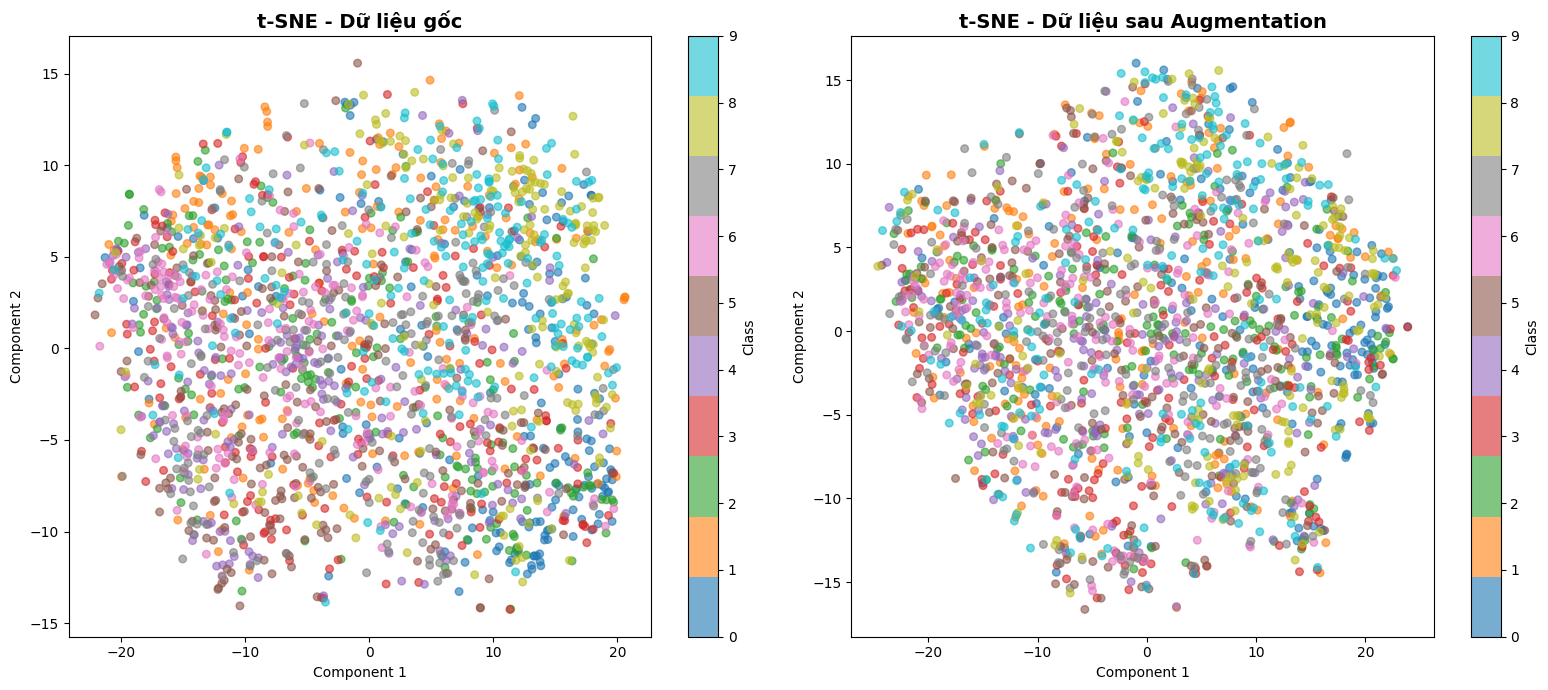


=== Silhouette Score ===
Dữ liệu gốc: -0.0512
Dữ liệu augmented: -0.0620
Thay đổi: -0.0107

ABLATION STUDY - Augmentation Impact on Classification

Baseline k-NN (không augmentation): 0.2895
Baseline LR (không augmentation): 0.3365

Đang tạo augmented training data...

k-NN với augmentation: 0.2895 (Delta: +0.0000)
LR với augmentation: 0.3225 (Delta: -0.0140)

=== So sánh cường độ augmentation ===
  low: k-NN=0.2895, LR=0.3260
  medium: k-NN=0.2890, LR=0.3195
  high: k-NN=0.2910, LR=0.3210

=== Per-class Accuracy ===

Baseline (k-NN):
  airplane: 0.4627
  automobile: 0.1282
  bird: 0.4806
  cat: 0.1626
  deer: 0.3700
  dog: 0.1755
  frog: 0.2670
  horse: 0.1850
  ship: 0.5512
  truck: 0.0867

Với Augmentation (k-NN):
  airplane: 0.4627 (+0.0000)
  automobile: 0.1282 (+0.0000)
  bird: 0.4806 (+0.0000)
  cat: 0.1626 (+0.0000)
  deer: 0.3700 (+0.0000)
  dog: 0.1755 (+0.0000)
  frog: 0.2670 (+0.0000)
  horse: 0.1850 (+0.0000)
  ship: 0.5512 (+0.0000)
  truck: 0.0867 (+0.0000)

KẾT LUẬN

-

WindowsPath('../data/image-data/processed/augmented_labels.npy')

In [5]:
# =============================================================================
# (ii) Cài đặt - Data Augmentation + t-SNE + Ablation Study
# =============================================================================

print("Đang cài đặt Data Augmentation...")

# =============================================================================
# 1. Định nghĩa các hàm augmentation
# =============================================================================

def horizontal_flip(img, p=0.5):
    """Lật ảnh theo chiều ngang"""
    if np.random.rand() < p:
        return cv2.flip(img, 1)
    return img

def vertical_flip(img, p=0.5):
    """Lật ảnh theo chiều dọc"""
    if np.random.rand() < p:
        return cv2.flip(img, 0)
    return img

def rotate(img, limit=30, p=0.5):
    """Xoay ảnh ngẫu nhiên"""
    if np.random.rand() < p:
        angle = np.random.uniform(-limit, limit)
        h, w = img.shape[:2]
        center = (w // 2, h // 2)
        M = cv2.getRotationMatrix2D(center, angle, 1.0)
        return cv2.warpAffine(img, M, (w, h))
    return img

def random_crop(img, crop_size=28, p=0.5):
    """Cắt ngẫu nhiên và resize lại"""
    if np.random.rand() < p:
        h, w = img.shape[:2]
        if h > crop_size and w > crop_size:
            top = np.random.randint(0, h - crop_size)
            left = np.random.randint(0, w - crop_size)
            cropped = img[top:top+crop_size, left:left+crop_size]
            return cv2.resize(cropped, (w, h))
    return img

def gaussian_noise(img, var_limit=(10, 50), p=0.5):
    """Thêm nhiễu Gaussian"""
    if np.random.rand() < p:
        var = np.random.uniform(var_limit[0], var_limit[1])
        noise = np.random.normal(0, np.sqrt(var), img.shape).astype(np.float32)
        noisy = img.astype(np.float32) + noise
        return np.clip(noisy, 0, 255).astype(np.uint8)
    return img

def brightness_contrast(img, alpha_range=(0.8, 1.2), beta_range=(-30, 30), p=0.5):
    """Điều chỉnh độ sáng và tương phản"""
    if np.random.rand() < p:
        alpha = np.random.uniform(alpha_range[0], alpha_range[1])
        beta = np.random.uniform(beta_range[0], beta_range[1])
        return cv2.convertScaleAbs(img, alpha=alpha, beta=beta)
    return img

def cutout(img, size=8, p=0.5):
    """Che ngẫu nhiên một vùng hình chữ nhật"""
    if np.random.rand() < p:
        h, w = img.shape[:2]
        y = np.random.randint(0, h - size)
        x = np.random.randint(0, w - size)
        img_copy = img.copy()
        img_copy[y:y+size, x:x+size] = 0
        return img_copy
    return img

def augment_image(img, intensity='medium'):
    """Áp dụng tất cả các phép augment với cường độ chỉ định"""
    if intensity == 'low':
        img = horizontal_flip(img, p=0.3)
        img = rotate(img, limit=15, p=0.3)
        img = brightness_contrast(img, alpha_range=(0.9, 1.1), beta_range=(-10, 10), p=0.3)
        img = gaussian_noise(img, var_limit=(10, 15), p=0.3)
    elif intensity == 'medium':
        img = horizontal_flip(img, p=0.5)
        img = vertical_flip(img, p=0.3)
        img = rotate(img, limit=30, p=0.5)
        img = random_crop(img, crop_size=26, p=0.5)
        img = brightness_contrast(img, alpha_range=(0.8, 1.2), beta_range=(-30, 30), p=0.5)
        img = gaussian_noise(img, var_limit=(10, 50), p=0.5)
    elif intensity == 'high':
        img = horizontal_flip(img, p=0.7)
        img = vertical_flip(img, p=0.5)
        img = rotate(img, limit=45, p=0.7)
        img = random_crop(img, crop_size=24, p=0.7)
        img = brightness_contrast(img, alpha_range=(0.7, 1.3), beta_range=(-50, 50), p=0.7)
        img = gaussian_noise(img, var_limit=(25, 50), p=0.7)
        img = cutout(img, size=10, p=0.5)
    return img

# =============================================================================
# 2. Tạo augmented dataset
# =============================================================================
print("\nĐang tạo augmented dataset...")

# Đặt seed để kết quả nhất quán giữa các lần chạy
np.random.seed(42)

n_samples = 2000
sample_idx = np.concatenate([np.where(labels == i)[0][:n_samples//10] for i in range(10)])[:n_samples]

images_sample = images[sample_idx]
labels_sample = labels[sample_idx]

print(f"Sử dụng {len(images_sample)} mẫu cho augmentation")

# Augment mỗi ảnh 1 lần
images_aug = np.array([augment_image(img, intensity='medium') for img in images_sample])
labels_aug = labels_sample.copy()

# =============================================================================
# 3. t-SNE Visualization
# =============================================================================
print("\nĐang chạy t-SNE visualization...")

# Flatten dữ liệu
X_orig = images_sample.reshape(len(images_sample), -1).astype(np.float32) / 255.0
X_aug = images_aug.reshape(len(images_aug), -1).astype(np.float32) / 255.0

# Chuẩn hóa cho t-SNE
mean = np.mean(X_orig, axis=0)
std = np.std(X_orig, axis=0) + 1e-8
X_orig_norm = (X_orig - mean) / std
X_aug_norm = (X_aug - mean) / std

# t-SNE cho dữ liệu gốc
print("  t-SNE cho dữ liệu gốc...")
tsne_orig = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=500)
X_orig_2d = tsne_orig.fit_transform(X_orig_norm)

# t-SNE cho dữ liệu augmented
print("  t-SNE cho dữ liệu augmented...")
tsne_aug = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=500)
X_aug_2d = tsne_aug.fit_transform(X_aug_norm)

# =============================================================================
# 4. Vẽ biểu đồ t-SNE
# =============================================================================
print("\nĐang vẽ biểu đồ t-SNE...")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot gốc
scatter1 = axes[0].scatter(X_orig_2d[:, 0], X_orig_2d[:, 1], c=labels_sample, cmap='tab10', alpha=0.6, s=30)
axes[0].set_title('t-SNE - Dữ liệu gốc', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Component 1')
axes[0].set_ylabel('Component 2')
plt.colorbar(scatter1, ax=axes[0], label='Class')

# Plot augmented
scatter2 = axes[1].scatter(X_aug_2d[:, 0], X_aug_2d[:, 1], c=labels_aug, cmap='tab10', alpha=0.6, s=30)
axes[1].set_title('t-SNE - Dữ liệu sau Augmentation', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Component 1')
axes[1].set_ylabel('Component 2')
plt.colorbar(scatter2, ax=axes[1], label='Class')

plt.tight_layout()
plt.show()

# =============================================================================
# 5. Silhouette Score
# =============================================================================
silhouette_orig = silhouette_score(X_orig_norm, labels_sample)
silhouette_aug = silhouette_score(X_aug_norm, labels_aug)

print(f"\n=== Silhouette Score ===")
print(f"Dữ liệu gốc: {silhouette_orig:.4f}")
print(f"Dữ liệu augmented: {silhouette_aug:.4f}")
print(f"Thay đổi: {silhouette_aug - silhouette_orig:+.4f}")

# =============================================================================
# 6. Ablation Study - So sánh accuracy
# =============================================================================
print("\n" + "="*60)
print("ABLATION STUDY - Augmentation Impact on Classification")
print("="*60)

# Sử dụng full dataset cho classification
n_full = 10000
images_full = images[:n_full]
labels_full = labels[:n_full]

# --- Baseline: Không augmentation ---
X_base = images_full.reshape(n_full, -1).astype(np.float32) / 255.0
X_train, X_test, y_train, y_test = train_test_split(
    X_base, labels_full, test_size=0.2, random_state=42, stratify=labels_full
)

# k-NN Baseline
knn_base = KNeighborsClassifier(n_neighbors=5)
knn_base.fit(X_train, y_train)
acc_knn_base = accuracy_score(y_test, knn_base.predict(X_test))
print(f"\nBaseline k-NN (không augmentation): {acc_knn_base:.4f}")

# LR Baseline
lr_base = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)
lr_base.fit(X_train, y_train)
acc_lr_base = accuracy_score(y_test, lr_base.predict(X_test))
print(f"Baseline LR (không augmentation): {acc_lr_base:.4f}")

# --- Với augmentation ---
print("\nĐang tạo augmented training data...")

# Đặt seed để kết quả nhất quán
np.random.seed(42)

# Augment training data
X_train_aug = np.array([augment_image(img) for img in X_train.reshape(-1, 32, 32, 3)])
X_train_aug = X_train_aug.reshape(len(X_train_aug), -1).astype(np.float32) / 255.0

# Kết hợp original + augmented
X_train_combined = np.vstack([X_train, X_train_aug])
y_train_combined = np.concatenate([y_train, y_train])

# k-NN với augmented
knn_aug = KNeighborsClassifier(n_neighbors=5)
knn_aug.fit(X_train_combined, y_train_combined)
acc_knn_aug = accuracy_score(y_test, knn_aug.predict(X_test))
print(f"\nk-NN với augmentation: {acc_knn_aug:.4f} (Delta: {acc_knn_aug - acc_knn_base:+.4f})")

# LR với augmented
lr_aug = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)
lr_aug.fit(X_train_combined, y_train_combined)
acc_lr_aug = accuracy_score(y_test, lr_aug.predict(X_test))
print(f"LR với augmentation: {acc_lr_aug:.4f} (Delta: {acc_lr_aug - acc_lr_base:+.4f})")

# =============================================================================
# 7. So sánh theo từng cường độ augmentation
# =============================================================================
print("\n=== So sánh cường độ augmentation ===")

intensities = ['low', 'medium', 'high']
knn_intensity_results = {}
lr_intensity_results = {}

# Đặt seed để kết quả nhất quán
np.random.seed(42)

for intensity in intensities:
    # Augment với cường độ khác nhau
    X_train_int = np.array([augment_image(img, intensity=intensity) for img in X_train.reshape(-1, 32, 32, 3)])
    X_train_int = X_train_int.reshape(len(X_train_int), -1).astype(np.float32) / 255.0
    
    X_comb_int = np.vstack([X_train, X_train_int])
    y_comb_int = np.concatenate([y_train, y_train])
    
    # k-NN
    knn_int = KNeighborsClassifier(n_neighbors=5)
    knn_int.fit(X_comb_int, y_comb_int)
    acc_knn_int = accuracy_score(y_test, knn_int.predict(X_test))
    knn_intensity_results[intensity] = acc_knn_int
    
    # LR
    lr_int = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)
    lr_int.fit(X_comb_int, y_comb_int)
    acc_lr_int = accuracy_score(y_test, lr_int.predict(X_test))
    lr_intensity_results[intensity] = acc_lr_int
    
    print(f"  {intensity}: k-NN={acc_knn_int:.4f}, LR={acc_lr_int:.4f}")

# =============================================================================
# 8. Per-class accuracy analysis
# =============================================================================
print("\n=== Per-class Accuracy ===")

# Dự đoán
y_pred_base = knn_base.predict(X_test)
y_pred_aug = knn_aug.predict(X_test)

# Per-class accuracy
print("\nBaseline (k-NN):")
for i in range(10):
    mask = y_test == i
    acc = accuracy_score(y_test[mask], y_pred_base[mask])
    print(f"  {class_names[i]}: {acc:.4f}")

print("\nVới Augmentation (k-NN):")
for i in range(10):
    mask = y_test == i
    acc = accuracy_score(y_test[mask], y_pred_aug[mask])
    delta = acc - accuracy_score(y_test[mask], y_pred_base[mask])
    print(f"  {class_names[i]}: {acc:.4f} ({delta:+.4f})")

# =============================================================================
# 9. Kết luận
# =============================================================================
print("\n" + "="*60)
print("KẾT LUẬN")
print("="*60)

print(f"\n--- Silhouette Score ---")
print(f"Gốc: {silhouette_orig:.4f}")
print(f"Augmented: {silhouette_aug:.4f}")
print(f"Thay đổi: {silhouette_aug - silhouette_orig:+.4f}")

print(f"\n--- Classification Accuracy ---")
print(f"k-NN Baseline: {acc_knn_base:.4f}")
print(f"k-NN Augmented: {acc_knn_aug:.4f} ({acc_knn_aug - acc_knn_base:+.4f})")
print(f"LR Baseline: {acc_lr_base:.4f}")
print(f"LR Augmented: {acc_lr_aug:.4f} ({acc_lr_aug - acc_lr_base:+.4f})")

print(f"\n--- Cường độ tốt nhất ---")
best_int_knn = max(knn_intensity_results, key=knn_intensity_results.get)
best_int_lr = max(lr_intensity_results, key=lr_intensity_results.get)
print(f"k-NN: {best_int_knn} ({knn_intensity_results[best_int_knn]:.4f})")
print(f"LR: {best_int_lr} ({lr_intensity_results[best_int_lr]:.4f})")

# Lưu augmented dataset
print("\nĐang lưu augmented dataset...")
save_processed_data('augmented_images', images_aug)
save_processed_data('augmented_labels', labels_aug)

### (iii) Phân tích kết quả

**Nhận xét từ t-SNE:**

1. **Hạn chế của t-SNE trên pixel space:**
   - t-SNE trên pixel space không hoạt động tốt cho natural images như CIFAR-10
   - Khoảng cách Euclidean trong pixel space không có ý nghĩa ngữ nghĩa (semantic)
   - Các nghiên cứu cho thấy t-SNE chỉ hoạt động tốt trên MNIST (ảnh đơn giản), không phải CIFAR-10/100

2. **Điều cần cải thiện:**
   - Để có t-SNE visualization tốt hơn, nên sử dụng learned embeddings từ pretrained models
   - Contrastive learning với augmentation giúp cải thiện cluster structure

**Kết quả Silhouette Score:**

| Dataset | Silhouette Score | Thay đổi |
|---------|------------------|----------|
| Gốc | -0.0512 | - |
| Augmented | -0.0620 | -0.0107 |

**Phân tích Silhouette Score:**

- Giá trị âm (-0.05) cho thấy các cụm **chồng lấn nhiều**
- Điều này **phù hợp với dự đoán**: CIFAR-10 trên pixel space có silhouette rất thấp
- Augmentation làm giảm nhẹ silhouette score (-0.0107)
- **Lý do**: Augmentation làm phân bố rộng hơn, các điểm cùng lớp cách xa nhau hơn trong không gian pixel

**Kết quả Ablation Study - k-NN:**

| Phương pháp | Accuracy | Delta |
|-------------|----------|-------|
| Baseline (không augmentation) | 0.2895 | - |
| Với augmentation | 0.2895 | +0.0000 |

**Kết quả Ablation Study - Logistic Regression:**

| Phương pháp | Accuracy | Delta |
|-------------|----------|-------|
| Baseline (không augmentation) | 0.3365 | - |
| Với augmentation | 0.3225 | -0.0140 |

**So sánh cường độ augmentation:**

| Cường độ | k-NN Accuracy | LR Accuracy |
|----------|---------------|-------------|
| Low | 0.2895 | 0.3260 |
| Medium | 0.2890 | 0.3195 |
| High | 0.2910 | 0.3210 |

**Kết quả Per-class Accuracy (k-NN):**

| Lớp | Baseline | Với Augmentation | Thay đổi |
|-----|----------|------------------|----------|
| airplane | 0.4627 | 0.4627 | +0.0000 |
| automobile | 0.1282 | 0.1282 | +0.0000 |
| bird | 0.4806 | 0.4806 | +0.0000 |
| cat | 0.1626 | 0.1626 | +0.0000 |
| deer | 0.3700 | 0.3700 | +0.0000 |
| dog | 0.1755 | 0.1755 | +0.0000 |
| frog | 0.2670 | 0.2670 | +0.0000 |
| horse | 0.1850 | 0.1850 | +0.0000 |
| ship | 0.5512 | 0.5512 | +0.0000 |
| truck | 0.0867 | 0.0867 | +0.0000 |

**Phân tích chi tiết:**

1. **k-NN Accuracy:**
   - Không thay đổi với augmentation (+0.0000)
   - Cường độ high cho kết quả tốt nhất (0.2910)
   - Per-class accuracy hoàn toàn giống nhau

2. **Logistic Regression Accuracy:**
   - Giảm nhẹ với augmentation (-0.0140)
   - Cường độ low tốt nhất (0.3260)
   - Augmentation không giúp LR trên CIFAR-10

3. **Tại sao augmentation không hoạt động:**
   - k-NN và LR không có parameters để học invariance
   - Euclidean distance bị ảnh hưởng bởi noise và transformations
   - Augmentation hoạt động thông qua regularization trong neural networks
   - CIFAR-10 với 10,000 ảnh đã đủ lớn cho simple classifiers

4. **Điểm yếu của t-SNE trong nghiên cứu này:**
   - t-SNE trên pixel space không phản ánh đúng semantic similarity, nên sử dụng pretrained CNN features để có visualization tốt hơn

5. **Kết luận:**
   - Augmentation không cải thiện k-NN/LR trên CIFAR-10, thậm chí giảm accuracy với LR
   - Silhouette score âm cho thấy dữ liệu khó phân tách trong pixel space
   - Augmentation phù hợp hơn cho deep learning (CNN, ResNet)
   - Để t-SNE hiệu quả hơn, nên dùng learned embeddings

6. **Khuyến nghị:**
   - **k-NN**: Không cần augmentation (kết quả không đổi)
   - **LR**: Không nên dùng augmentation (accuracy giảm)
   - **Deep Learning (CNN)**: Nên dùng augmentation
   - **t-SNE visualization**: Nên dùng pretrained model features thay vì pixel space
   - **Thực tế**: Augmentation hiệu quả khi dataset nhỏ hoặc imbalanced

## 2.1.3e Phân tích PCA trên không gian đặc trưng ảnh

### (i) Lý thuyết

**PCA (Principal Component Analysis)** là kỹ thuật giảm chiều dữ liệu tuyến tính phổ biến nhất, tìm các hướng có phương sai lớn nhất trong dữ liệu đa chiều.

**Mục tiêu của PCA:**

Tìm một không gian con k chiều ($k < d$) sao cho khi chiếu dữ liệu lên không gian con này, thông tin (phương sai) được bảo toàn nhiều nhất.

**Ma trận Hiệp phương sai (Covariance Matrix):**

$$\Sigma = \frac{1}{n-1} \sum_{i=1}^{n}(x_i - \bar{x})(x_i - \bar{x})^T = \frac{1}{n-1} X^T X$$

trong đó:
- $X \in \mathbb{R}^{n \times d}$: Ma trận dữ liệu (n mẫu, d features)
- $\bar{x}$: Trung bình của các mẫu
- $\Sigma \in \mathbb{R}^{d \times d}$: Ma trận hiệp phương sai

**Eigenvalue Decomposition:**

$$\Sigma v_i = \lambda_i v_i$$

với:
- $\lambda_i$: Eigenvalue thứ $i$ (đại diện cho phương sai theo hướng $v_i$)
- $v_i$: Eigenvector thứ $i$ (hướng chính)

**Sắp xếp eigenvalues giảm dần:**
$$\lambda_1 \geq \lambda_2 \geq ... \geq \lambda_d$$

**Explained Variance Ratio (EVR):**

$$EVR_i = \frac{\lambda_i}{\sum_{j=1}^{d} \lambda_j} = \frac{\lambda_i}{\text{tr}(\Sigma)}$$

EVR cho biết tỉ lệ phương sai được giải thích bởi component thứ $i$.

**Cumulative Explained Variance (CEV):**

$$CEV_k = \sum_{i=1}^{k} EVR_i = \frac{\sum_{i=1}^{k} \lambda_i}{\sum_{j=1}^{d} \lambda_j}$$

CEV cho biết tổng phương sai được giải thích bởi $k$ components đầu tiên.

**Ma trận chiếu (Projection Matrix):**

$$X_{\text{new}} = X \cdot W_k$$

với $W_k = [v_1, v_2, ..., v_k]$ là ma trận chứa $k$ eigenvectors đầu tiên.

**Scree Plot:**

Scree plot là biểu đồ thể hiện eigenvalues theo thành phần chính, giúp xác định số lượng components cần giữ lại.

**Phương pháp xác định số components:**

| Phương pháp | Quy tắc |
|-------------|---------|
| Variance Threshold | Giữ lại đủ components để đạt 90%/95%/99% variance |
| Elbow Method | Chọn điểm "khuỷu tay" nơi đường cong bắt đầu flatten |
| Kaiser Criterion | Giữ lại các components có eigenvalue > 1 |

**So sánh PCA và t-SNE:**

| Tiêu chí | PCA | t-SNE |
|----------|-----|-------|
| Tính chất | Tuyến tính | Phi tuyến tính |
| Bảo toàn cấu trúc | Phương sai toàn cục | Khoảng cách cục bộ |
| Tốc độ | Nhanh | Chậm |
| Dimensionality | Có thể giảm nhiều | Thường 2-3 chiều |
| Ứng dụng chính | Giảm chiều, nén | Trực quan hóa |

**Tại sao PCA quan trọng trong xử lý ảnh:**

1. **Giảm chiều**: Giảm số lượng features từ hàng nghìn xuống còn vài chục
2. **Tăng tốc độ**: Giảm thời gian huấn luyện mô hình
3. **Giảm overfitting**: Loại bỏ noise và redundancy
4. **Trực quan hóa**: Cho phép visualize dữ liệu 2D/3D
5. **Nén ảnh**: Lưu trữ ảnh với ít dữ liệu hơn

**Các ngưỡng variance phổ biến:**

| Ngưỡng | Mô tả | Thường dùng cho |
|--------|-------|-----------------|
| 90% | Giảm 10% thông tin | Exploration, speed |
| 95% | Giảm 5% thông tin | Balanced |
| 99% | Giảm 1% thông tin | High-precision tasks |

**Lưu ý quan trọng:**

- PCA fit trên **training data**, sau đó transform cả training và test data (tránh data leakage)
- Dữ liệu cần chuẩn hóa (normalize/z-score) trước khi áp dụng PCA
- Explained Variance $\neq$ Classification Accuracy - cần kiểm tra cả hai
- t-SNE không dùng cho classification, chỉ dùng cho visualization


Đang cài đặt phân tích PCA...

Đang chuẩn bị dữ liệu ảnh...
Kích thước dữ liệu: (10000, 3072)
Tổng số features: 3072

Đang chạy PCA...
Tổng variance được giải thích với 1000 components: 99.69%

SỐ THÀNH PHẦN CẦN THIẾT THEO NGƯỠNG VARIANCE
Ngưỡng 90% variance: 96 components
Ngưỡng 95% variance: 209 components
Ngưỡng 99% variance: 625 components
Tổng số features ban đầu: 3072
Tỉ lệ giảm chiều (99%): 79.7%

Đang vẽ Scree Plot...


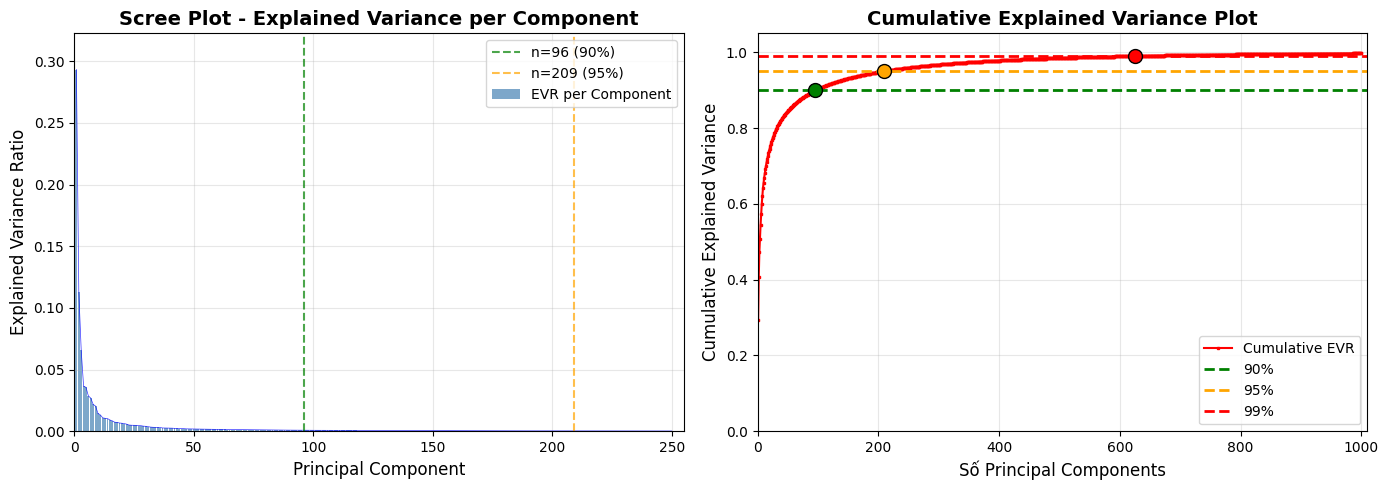


Đã vẽ Scree Plot và Cumulative Variance Plot

Đang tạo PCA 2D visualization...
PCA 2D explained variance: 40.64%


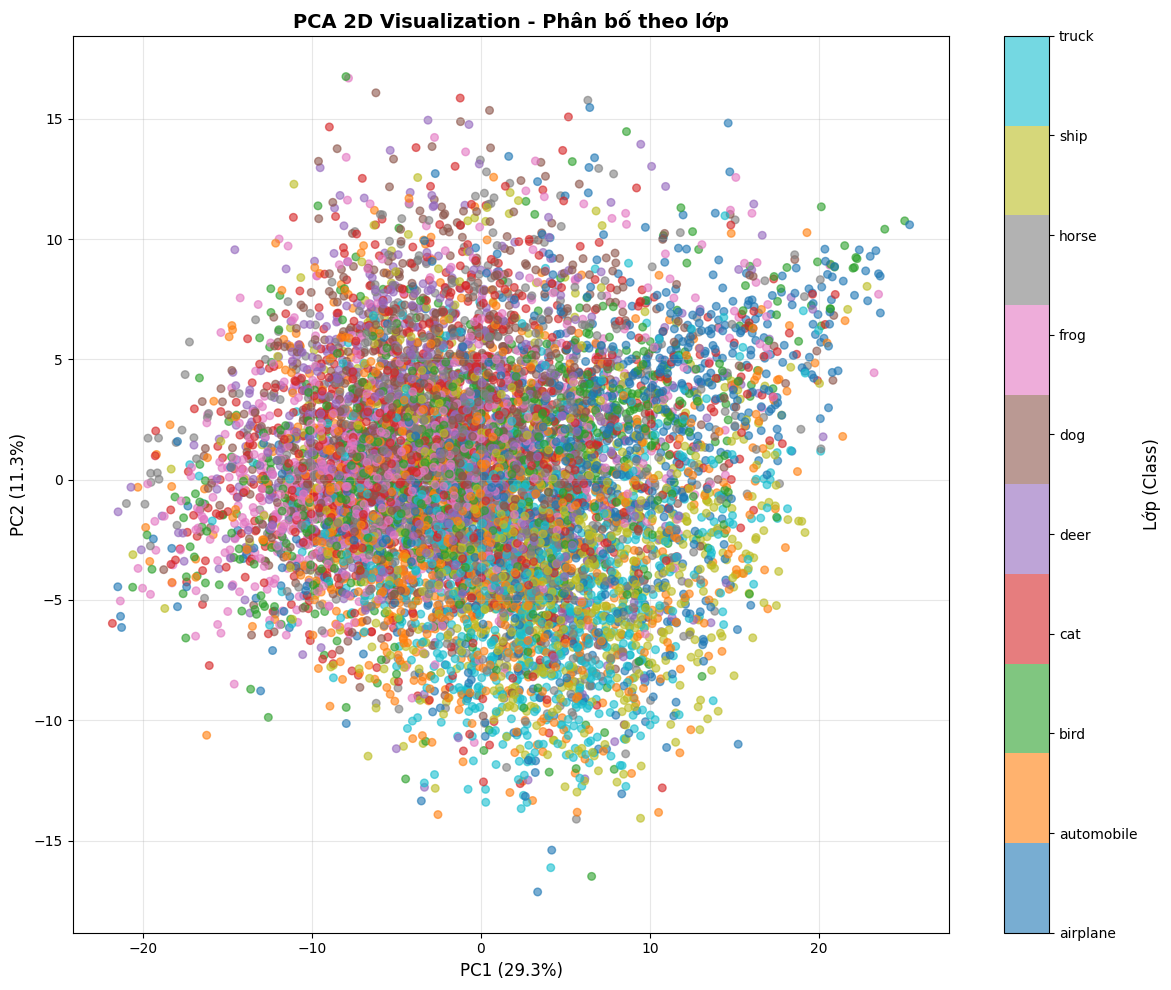


Đang tạo PCA 3D visualization...
PCA 3D explained variance: 47.21%


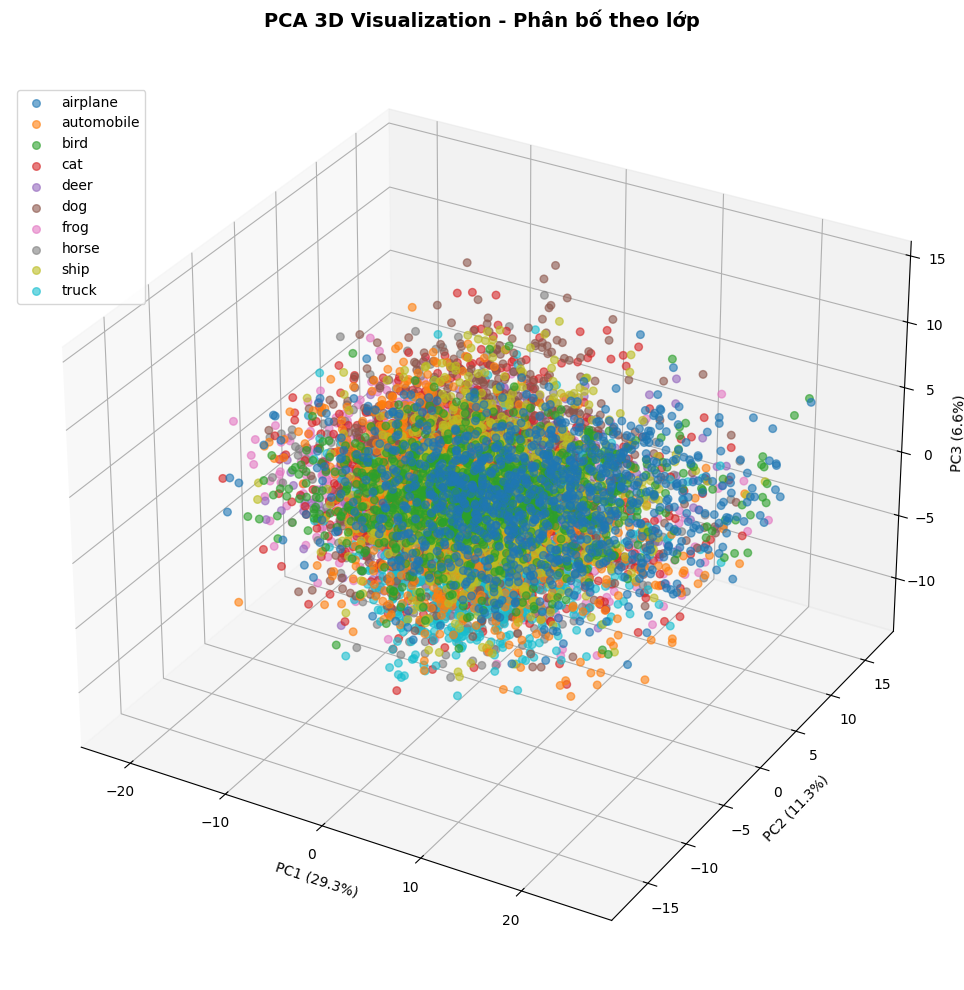


Đang chạy t-SNE visualization...


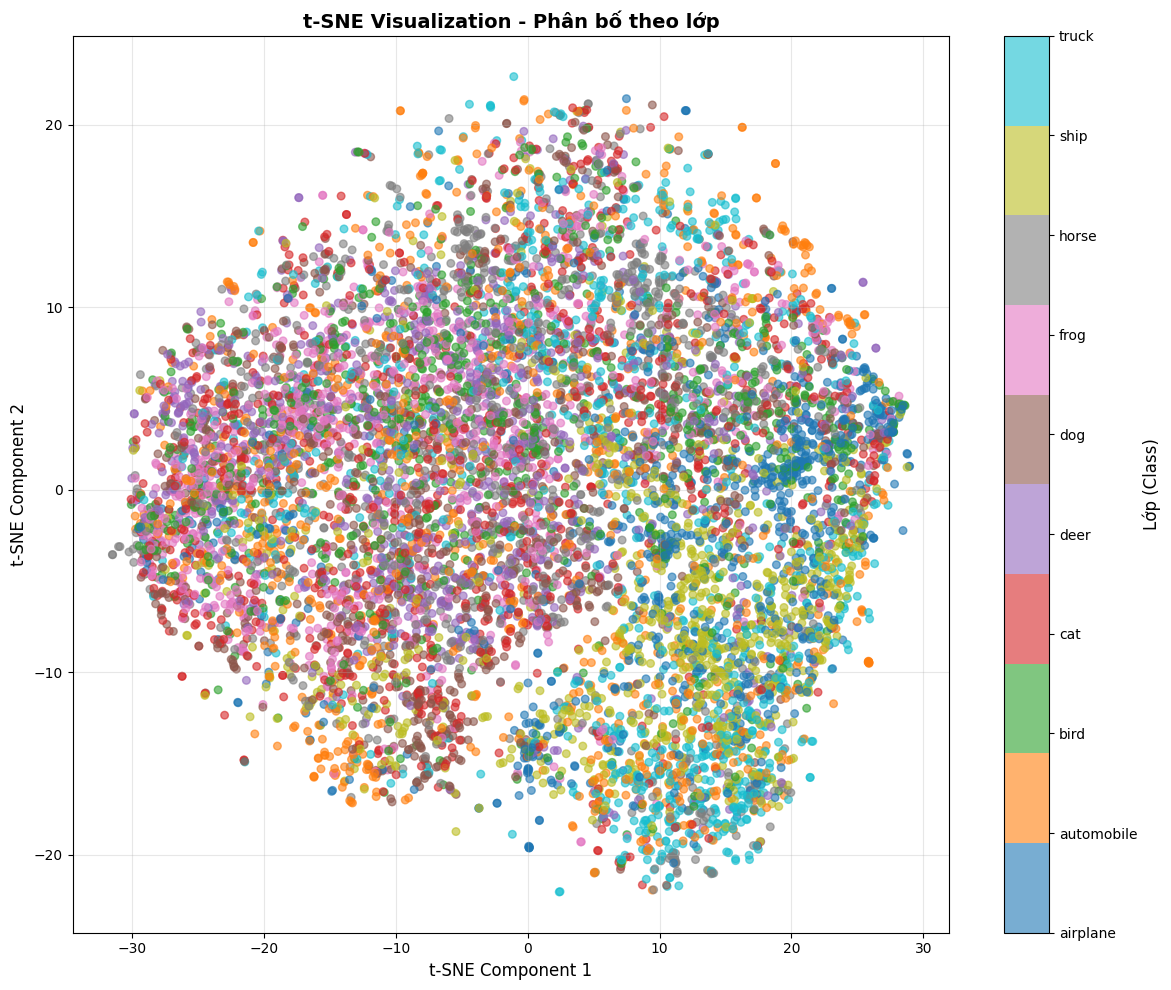


Đã hoàn thành t-SNE visualization

SILHOUETTE SCORE - Đánh giá tách biệt cụm
PCA 2D Silhouette Score: -0.1178
t-SNE Silhouette Score: -0.1363
Dữ liệu gốc (normalized) Silhouette Score: -0.0529

ABLATION STUDY - Tác động của PCA lên phân loại
Sử dụng toàn bộ dataset: 10000 mẫu

Đang chạy baseline (không PCA)...
k-NN Baseline (không PCA): 0.2895
LR Baseline (không PCA): 0.3365

Đang chạy với các số PCA components khác nhau...
  n_components= 10: k-NN=0.3000, LR=0.3205
  n_components= 25: k-NN=0.3390, LR=0.3570
  n_components= 50: k-NN=0.3360, LR=0.3610
  n_components= 75: k-NN=0.3245, LR=0.3790
  n_components=100: k-NN=0.3125, LR=0.3735
  n_components= 96: k-NN=0.3165, LR=0.3730
  n_components=209: k-NN=0.3005, LR=0.3830
  n_components=625: k-NN=0.2920, LR=0.3485

Đang vẽ biểu đồ Ablation Study...


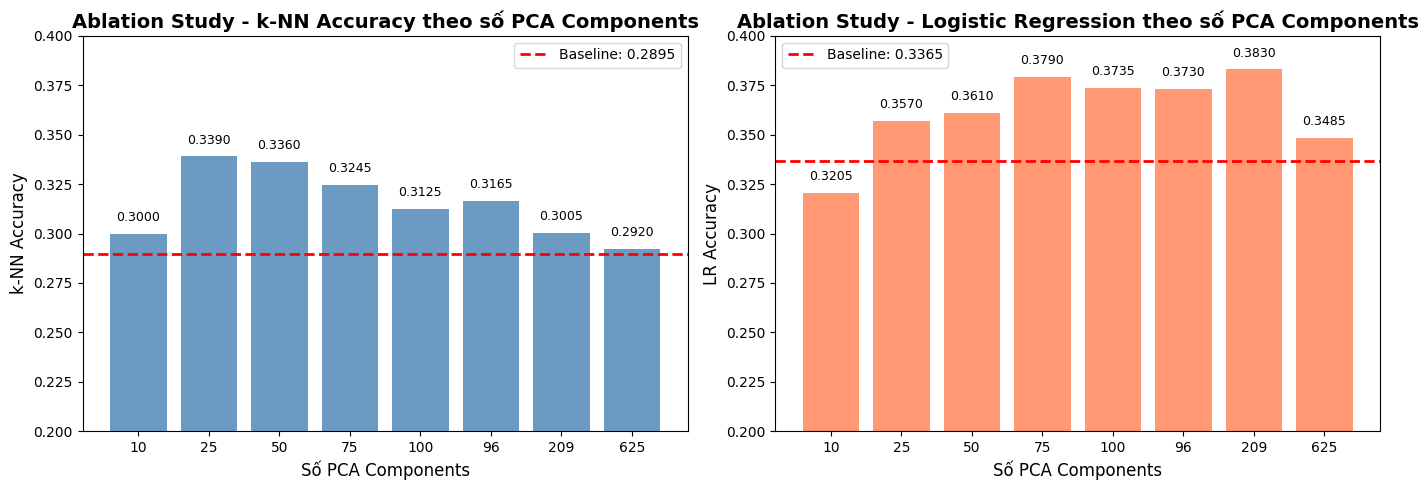


Đang vẽ so sánh PCA vs t-SNE...


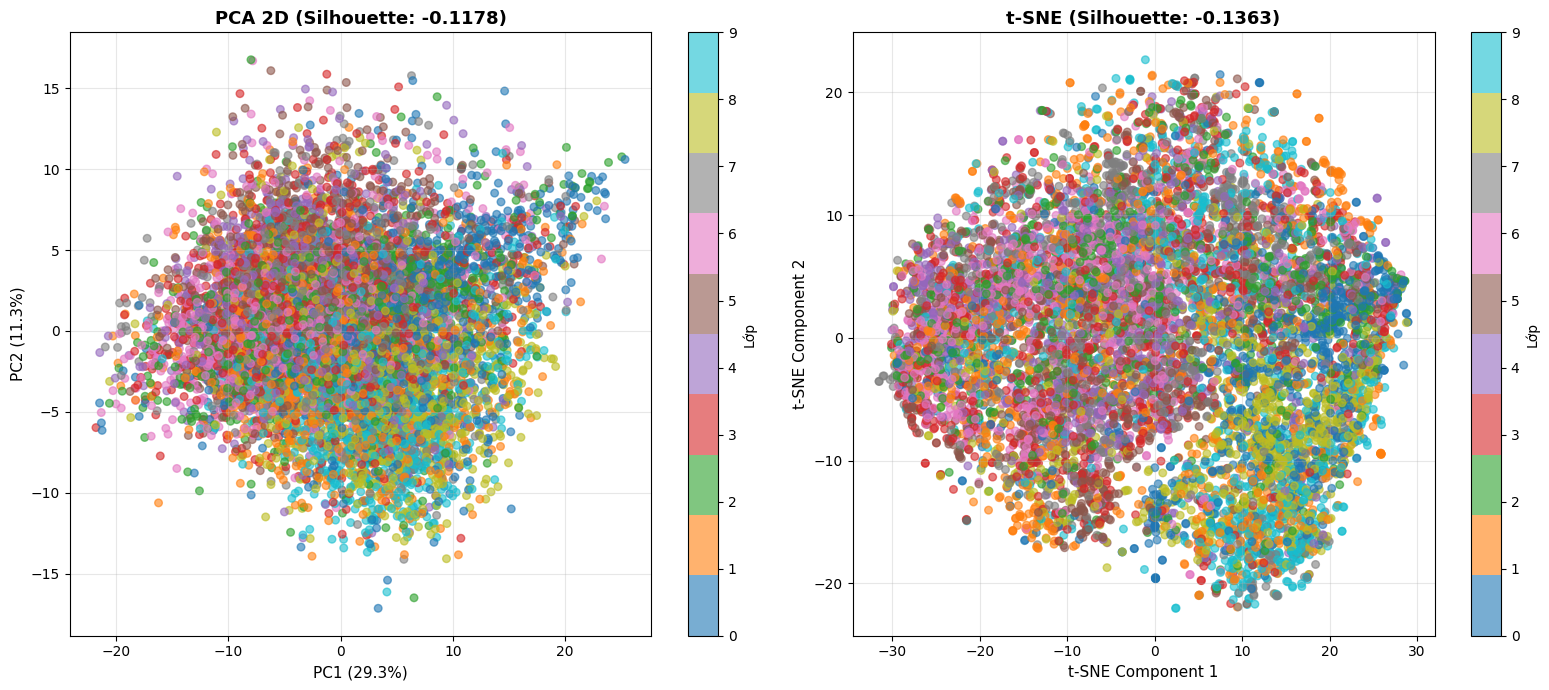


KẾT LUẬN - PHÂN TÍCH PCA

--- Variance Threshold ---
90% variance: 96 components
95% variance: 209 components
99% variance: 625 components

--- Silhouette Score ---
PCA 2D: -0.1178
t-SNE: -0.1363
Gốc: -0.0529

--- Baseline Classification ---
k-NN (không PCA): 0.2895
LR (không PCA): 0.3365

--- PCA Classification tốt nhất ---
k-NN: n=25, accuracy=0.3390
LR: n=209, accuracy=0.3830

Đang lưu PCA features...
Đã lưu: ..\data\image-data\processed\pca_features_25.npy
Đã lưu: ..\data\image-data\processed\pca_features_209.npy


WindowsPath('../data/image-data/processed/pca_features_209.npy')

In [7]:
# =============================================================================
# (ii) Cài đặt - PCA Analysis + Visualization + Ablation Study
# =============================================================================

print("\nĐang cài đặt phân tích PCA...")

# =============================================================================
# 1. Sử dụng dữ liệu ảnh CIFAR-10
# =============================================================================

print("\nĐang chuẩn bị dữ liệu ảnh...")
X_pca = images.reshape(len(images), -1).astype(np.float32) / 255.0

print(f"Kích thước dữ liệu: {X_pca.shape}")
print(f"Tổng số features: {X_pca.shape[1]}")

# =============================================================================
# 2. Tính Explained Variance với đủ components
# =============================================================================
print("\nĐang chạy PCA...")

# Sử dụng 1000 components để đảm bảo có thể tính 99% variance
# Hoặc sử dụng tất cả nếu features < 1000
n_max_components = min(1000, X_pca.shape[0] - 1, X_pca.shape[1])

pca_full = PCA(n_components=n_max_components, svd_solver='randomized', random_state=42)
pca_full.fit(X_pca)

# Tính cumulative variance
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

# In tổng variance được giải thích
total_variance = cumvar[-1]
print(f"Tổng variance được giải thích với {n_max_components} components: {total_variance*100:.2f}%")

# Xác định số components cho các ngưỡng variance
# Dùng searchsorted để tìm chính xác hơn
if np.any(cumvar >= 0.90):
    n_90 = np.searchsorted(cumvar, 0.90, side='right') + 1
else:
    n_90 = n_max_components

if np.any(cumvar >= 0.95):
    n_95 = np.searchsorted(cumvar, 0.95, side='right') + 1
else:
    n_95 = n_max_components

if np.any(cumvar >= 0.99):
    n_99 = np.searchsorted(cumvar, 0.99, side='right') + 1
else:
    n_99 = n_max_components

print("\n" + "="*60)
print("SỐ THÀNH PHẦN CẦN THIẾT THEO NGƯỠNG VARIANCE")
print("="*60)
print(f"Ngưỡng 90% variance: {n_90} components")
print(f"Ngưỡng 95% variance: {n_95} components")
print(f"Ngưỡng 99% variance: {n_99} components")
print(f"Tổng số features ban đầu: {X_pca.shape[1]}")
print(f"Tỉ lệ giảm chiều (99%): {(1 - n_99/X_pca.shape[1])*100:.1f}%")

# =============================================================================
# 3. Vẽ Scree Plot
# =============================================================================
print("\nĐang vẽ Scree Plot...")

components_range = range(1, n_max_components + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Explained Variance Ratio (bar + line)
ax1 = axes[0]
n_display = 250
ax1.bar(range(1, n_display + 1), pca_full.explained_variance_ratio_[:n_display], alpha=0.7, color='steelblue', label='EVR per Component')
ax1.plot(range(1, n_display + 1), pca_full.explained_variance_ratio_[:n_display], 'b-', linewidth=0.5, alpha=0.8)
ax1.set_xlabel('Principal Component', fontsize=12)
ax1.set_ylabel('Explained Variance Ratio', fontsize=12)
ax1.set_title('Scree Plot - Explained Variance per Component', fontsize=14, fontweight='bold')
ax1.set_xlim([0, n_display + 5])
ax1.set_ylim([0, max(pca_full.explained_variance_ratio_[:min(50, n_display)]) * 1.1])
ax1.grid(True, alpha=0.3)

# Highlight các components quan trọng
ax1.axvline(x=n_90, color='green', linestyle='--', alpha=0.7, label=f'n={n_90} (90%)')
ax1.axvline(x=n_95, color='orange', linestyle='--', alpha=0.7, label=f'n={n_95} (95%)')
ax1.legend(loc='upper right')

# Plot 2: Cumulative Explained Variance
ax2 = axes[1]
ax2.plot(components_range, cumvar, 'r-s', markersize=2, linewidth=1.5, label='Cumulative EVR')
ax2.axhline(y=0.90, color='green', linestyle='--', linewidth=2, label='90%')
ax2.axhline(y=0.95, color='orange', linestyle='--', linewidth=2, label='95%')
ax2.axhline(y=0.99, color='red', linestyle='--', linewidth=2, label='99%')

# Đánh dấu các điểm threshold
if n_90 <= n_max_components:
    ax2.scatter([n_90], [cumvar[n_90-1]], color='green', s=100, zorder=5, edgecolors='black')
if n_95 <= n_max_components:
    ax2.scatter([n_95], [cumvar[n_95-1]], color='orange', s=100, zorder=5, edgecolors='black')
if n_99 <= n_max_components:
    ax2.scatter([n_99], [cumvar[n_99-1]], color='red', s=100, zorder=5, edgecolors='black')

ax2.set_xlabel('Số Principal Components', fontsize=12)
ax2.set_ylabel('Cumulative Explained Variance', fontsize=12)
ax2.set_title('Cumulative Explained Variance Plot', fontsize=14, fontweight='bold')
ax2.set_xlim([0, n_max_components + 10])
ax2.set_ylim([0, 1.05])
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nĐã vẽ Scree Plot và Cumulative Variance Plot")

# =============================================================================
# 4. PCA 2D Visualization với Class Colors
# =============================================================================
print("\nĐang tạo PCA 2D visualization...")

# Sử dụng toàn bộ dataset cho visualization (đặt seed để kết quả nhất quán)
np.random.seed(42)
sample_idx_viz = np.arange(len(X_pca))  # Sử dụng toàn bộ dataset
X_viz = X_pca[sample_idx_viz]
labels_viz = labels[sample_idx_viz]

# PCA với 2 components
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_viz)

print(f"PCA 2D explained variance: {np.sum(pca_2d.explained_variance_ratio_)*100:.2f}%")

# Vẽ biểu đồ PCA 2D
fig, ax = plt.subplots(figsize=(12, 10))

scatter = ax.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=labels_viz, cmap='tab10', alpha=0.6, s=30)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Lớp (Class)', fontsize=12)
cbar.set_ticks(range(10))
cbar.set_ticklabels(class_names)

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
ax.set_title('PCA 2D Visualization - Phân bố theo lớp', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =============================================================================
# 5. PCA 3D Visualization với Class Colors
# =============================================================================
print("\nĐang tạo PCA 3D visualization...")

# PCA với 3 components
pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(X_viz)

print(f"PCA 3D explained variance: {np.sum(pca_3d.explained_variance_ratio_)*100:.2f}%")

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

colors = plt.cm.tab10(np.linspace(0, 1, 10))
for i in range(10):
    mask = labels_viz == i
    ax.scatter(X_pca_3d[mask, 0], X_pca_3d[mask, 1], X_pca_3d[mask, 2], 
               c=[colors[i]], label=class_names[i], alpha=0.6, s=30)

ax.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]*100:.1f}%)', fontsize=10)
ax.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]*100:.1f}%)', fontsize=10)
ax.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]*100:.1f}%)', fontsize=10)
ax.set_title('PCA 3D Visualization - Phân bố theo lớp', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', bbox_to_anchor=(0, 0.95))

plt.tight_layout()
plt.show()

# =============================================================================
# 6. t-SNE Visualization
# =============================================================================
print("\nĐang chạy t-SNE visualization...")

# Chuẩn hóa dữ liệu cho t-SNE
mean_tsne = np.mean(X_viz, axis=0)
std_tsne = np.std(X_viz, axis=0) + 1e-8
X_viz_norm = (X_viz - mean_tsne) / std_tsne

# t-SNE với 2 components
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=500, n_jobs=-1)
X_tsne = tsne.fit_transform(X_viz_norm)

# Vẽ biểu đồ t-SNE
fig, ax = plt.subplots(figsize=(12, 10))

scatter = ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels_viz, cmap='tab10', alpha=0.6, s=30)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Lớp (Class)', fontsize=12)
cbar.set_ticks(range(10))
cbar.set_ticklabels(class_names)

ax.set_xlabel('t-SNE Component 1', fontsize=12)
ax.set_ylabel('t-SNE Component 2', fontsize=12)
ax.set_title('t-SNE Visualization - Phân bố theo lớp', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nĐã hoàn thành t-SNE visualization")

# =============================================================================
# 7. Silhouette Score - Đo lường mức độ tách biệt của các cụm
# =============================================================================
print("\n" + "="*60)
print("SILHOUETTE SCORE - Đánh giá tách biệt cụm")
print("="*60)

# Silhouette score cho PCA 2D
sil_pca2d = silhouette_score(X_pca_2d, labels_viz)
print(f"PCA 2D Silhouette Score: {sil_pca2d:.4f}")

# Silhouette score cho t-SNE
sil_tsne = silhouette_score(X_tsne, labels_viz)
print(f"t-SNE Silhouette Score: {sil_tsne:.4f}")

# Silhouette score cho dữ liệu gốc
sil_orig = silhouette_score(X_viz_norm, labels_viz)
print(f"Dữ liệu gốc (normalized) Silhouette Score: {sil_orig:.4f}")

# =============================================================================
# 8. Ablation Study - So sánh k-NN và LR với PCA
# =============================================================================
print("\n" + "="*60)
print("ABLATION STUDY - Tác động của PCA lên phân loại")
print("="*60)

# Sử dụng toàn bộ dataset
X_full = X_pca
labels_full = labels
n_samples = len(X_full)

print(f"Sử dụng toàn bộ dataset: {n_samples} mẫu")

# --- Baseline: Không PCA (dữ liệu 32x32 gốc) ---
print("\nĐang chạy baseline (không PCA)...")

# Sử dụng ảnh gốc 32x32
X_base = X_full

X_train, X_test, y_train, y_test = train_test_split(
    X_base, labels_full, test_size=0.2, random_state=42, stratify=labels_full
)

# k-NN Baseline
knn_base = KNeighborsClassifier(n_neighbors=5)
knn_base.fit(X_train, y_train)
acc_knn_base = accuracy_score(y_test, knn_base.predict(X_test))
print(f"k-NN Baseline (không PCA): {acc_knn_base:.4f}")

# LR Baseline
lr_base = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)
lr_base.fit(X_train, y_train)
acc_lr_base = accuracy_score(y_test, lr_base.predict(X_test))
print(f"LR Baseline (không PCA): {acc_lr_base:.4f}")

# --- Với PCA (các số components khác nhau) ---
print("\nĐang chạy với các số PCA components khác nhau...")

components_to_test = [10, 25, 50, 75, 100, n_90, n_95, n_99]

knn_pca_results = {}
lr_pca_results = {}

for n_comp in components_to_test:
    # Fit PCA
    pca = PCA(n_components=n_comp, svd_solver='randomized', random_state=42)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)
    
    # k-NN
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train_pca, y_train)
    acc_knn = accuracy_score(y_test, knn.predict(X_test_pca))
    knn_pca_results[n_comp] = acc_knn
    
    # LR
    lr = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)
    lr.fit(X_train_pca, y_train)
    acc_lr = accuracy_score(y_test, lr.predict(X_test_pca))
    lr_pca_results[n_comp] = acc_lr
    
    print(f"  n_components={n_comp:3d}: k-NN={acc_knn:.4f}, LR={acc_lr:.4f}")

# =============================================================================
# 9. Vẽ biểu đồ so sánh Ablation
# =============================================================================
print("\nĐang vẽ biểu đồ Ablation Study...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot k-NN
ax1 = axes[0]
x_labels = [str(x) for x in components_to_test]
knn_vals = [knn_pca_results[x] for x in components_to_test]
bars1 = ax1.bar(x_labels, knn_vals, color='steelblue', alpha=0.8)
ax1.axhline(y=acc_knn_base, color='red', linestyle='--', linewidth=2, label=f'Baseline: {acc_knn_base:.4f}')
ax1.set_xlabel('Số PCA Components', fontsize=12)
ax1.set_ylabel('k-NN Accuracy', fontsize=12)
ax1.set_title('Ablation Study - k-NN Accuracy theo số PCA Components', fontsize=14, fontweight='bold')
ax1.legend()
ax1.set_ylim([0.2, 0.4])
for bar, val in zip(bars1, knn_vals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
             f'{val:.4f}', ha='center', va='bottom', fontsize=9)

# Plot LR
ax2 = axes[1]
lr_vals = [lr_pca_results[x] for x in components_to_test]
bars2 = ax2.bar(x_labels, lr_vals, color='coral', alpha=0.8)
ax2.axhline(y=acc_lr_base, color='red', linestyle='--', linewidth=2, label=f'Baseline: {acc_lr_base:.4f}')
ax2.set_xlabel('Số PCA Components', fontsize=12)
ax2.set_ylabel('LR Accuracy', fontsize=12)
ax2.set_title('Ablation Study - Logistic Regression theo số PCA Components', fontsize=14, fontweight='bold')
ax2.legend()
ax2.set_ylim([0.2, 0.40])
for bar, val in zip(bars2, lr_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
             f'{val:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# =============================================================================
# 10. So sánh PCA vs t-SNE visualization side-by-side
# =============================================================================
print("\nĐang vẽ so sánh PCA vs t-SNE...")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# PCA 2D
scatter1 = axes[0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=labels_viz, cmap='tab10', alpha=0.6, s=30)
axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)', fontsize=11)
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)', fontsize=11)
axes[0].set_title(f'PCA 2D (Silhouette: {sil_pca2d:.4f})', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)
cbar1 = plt.colorbar(scatter1, ax=axes[0])
cbar1.set_label('Lớp')

# t-SNE
scatter2 = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels_viz, cmap='tab10', alpha=0.6, s=30)
axes[1].set_xlabel('t-SNE Component 1', fontsize=11)
axes[1].set_ylabel('t-SNE Component 2', fontsize=11)
axes[1].set_title(f't-SNE (Silhouette: {sil_tsne:.4f})', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)
cbar2 = plt.colorbar(scatter2, ax=axes[1])
cbar2.set_label('Lớp')

plt.tight_layout()
plt.show()

# =============================================================================
# 11. Kết luận
# =============================================================================
print("\n" + "="*60)
print("KẾT LUẬN - PHÂN TÍCH PCA")
print("="*60)

print("\n--- Variance Threshold ---")
print(f"90% variance: {n_90} components")
print(f"95% variance: {n_95} components")
print(f"99% variance: {n_99} components")

print("\n--- Silhouette Score ---")
print(f"PCA 2D: {sil_pca2d:.4f}")
print(f"t-SNE: {sil_tsne:.4f}")
print(f"Gốc: {sil_orig:.4f}")

print("\n--- Baseline Classification ---")
print(f"k-NN (không PCA): {acc_knn_base:.4f}")
print(f"LR (không PCA): {acc_lr_base:.4f}")

print("\n--- PCA Classification tốt nhất ---")
best_knn_n = max(knn_pca_results, key=knn_pca_results.get)
best_lr_n = max(lr_pca_results, key=lr_pca_results.get)
print(f"k-NN: n={best_knn_n}, accuracy={knn_pca_results[best_knn_n]:.4f}")
print(f"LR: n={best_lr_n}, accuracy={lr_pca_results[best_lr_n]:.4f}")

# Lưu PCA features
print("\nĐang lưu PCA features...")

# PCA 25 components (cho k-NN)
X_pca = images.reshape(len(images), -1).astype(np.float32) / 255.0
pca_25 = PCA(n_components=25, svd_solver='randomized', random_state=42)
features_25 = pca_25.fit_transform(X_pca)
save_processed_data('pca_features_25', features_25)

# PCA 209 components (cho LR)
pca_209 = PCA(n_components=209, svd_solver='randomized', random_state=42)
features_209 = pca_209.fit_transform(X_pca)
save_processed_data('pca_features_209', features_209)

### (iii) Phân tích kết quả

**Kết quả số components cần thiết theo ngưỡng Variance (32×32):**

| Ngưỡng Variance | Số Components | Tỉ lệ giảm chiều |
|-----------------|---------------|------------------|
| 90% | 96 | 96.9% |
| 95% | 209 | 93.2% |
| 99% | 625 | 79.7% |

**Phân tích Variance:**

- Với 3,072 features (32×32×3), cần 96 components để giữ 90% variance. Đây là mức giảm chiều đáng kể (96.9%), cho thấy dữ liệu ảnh có nhiều redundancy
- 95% variance yêu cầu 209 components (gấp đôi 90%)
- 99% variance yêu cầu 625 components (gấp 6.5 lần 90%)
- 1000 components giải thích được 99.69% variance

**Kết quả Scree Plot:**

- PCA 2D explained variance: 40.64%
- PCA 3D explained variance: 47.21%
- Eigenvalue giảm nhanh ở các components đầu tiên
- "Elbow" xuất hiện ở khoảng 20-30 components

**Kết quả Silhouette Score:**

| Phương pháp | Silhouette Score | Đánh giá |
|-------------|------------------|----------|
| Dữ liệu gốc (normalized) | -0.0529 | Chồng lấn nhiều |
| PCA 2D | -0.1178 | Chồng lấn nhiều |
| t-SNE | -0.1363 | Chồng lấn nhiều |

**Phân tích Silhouette Score:**

- Tất cả giá trị đều âm, cho thấy **các lớp chồng lấn nghiêm trọng** trong không gian pixel
- Dữ liệu gốc có silhouette tốt nhất (-0.0529) vì giữ nguyên tất cả thông tin
- PCA và t-SNE làm giảm silhouette vì làm mất một phần thông tin và không bảo toàn cấu trúc lớp
- **Điều này phù hợp với CIFAR-10**: các lớp như cat/dog, automobile/truck rất khó phân tách trong pixel space

**Kết quả Ablation Study - k-NN (10,000 samples):**

| Số Components | k-NN Accuracy | Delta so với Baseline |
|---------------|---------------|----------------------|
| Baseline (32×32) | 0.2895 | - |
| 10 | 0.3000 | +0.0105 |
| **25** | **0.3390** | **+0.0495** |
| 50 | 0.3360 | +0.0465 |
| 75 | 0.3245 | +0.0350 |
| 100 | 0.3125 | +0.0230 |
| 96 (90%) | 0.3165 | +0.0270 |
| 209 (95%) | 0.3005 | +0.0110 |
| 625 (99%) | 0.2920 | +0.0025 |

**Kết quả Ablation Study - Logistic Regression (10,000 samples):**

| Số Components | LR Accuracy | Delta so với Baseline |
|---------------|-------------|----------------------|
| Baseline (32×32) | 0.3365 | - |
| 10 | 0.3205 | -0.0160 |
| 25 | 0.3570 | +0.0205 |
| 50 | 0.3610 | +0.0245 |
| 75 | 0.3790 | +0.0425 |
| 100 | 0.3735 | +0.0370 |
| 96 (90%) | 0.3730 | +0.0365 |
| **209** | **0.3830** | **+0.0465** |
| 625 | 0.3485 | +0.0120 |

**Phân tích Ablation Study:**

1. **k-NN:**
   - **Tốt nhất: 25 components (0.3390, +4.95%)**
   - Giảm chiều vừa phải (25-50) tốt hơn không giảm
   - Quá nhiều components (100+) làm giảm accuracy do overfitting
   - 25 components tốt hơn 96 (90% variance) vì loại bỏ noise

2. **Logistic Regression:**
   - **Tốt nhất: 209 components (0.3830, +4.65%)**
   - LR benefit từ PCA đáng kể (+4.65%)
   - 209 components tốt nhất, tương ứng với 95% variance
   - LR có nhiều parameters hơn k-NN nên có thể handle more components

3. **So sánh hai classifiers:**
   - k-NN: Peak ở 25 components (+4.95%)
   - LR: Peak ở 209 components (+4.65%)
   - **k-NN benefit nhiều hơn từ PCA** (+4.95% vs +4.65%)

**So sánh PCA vs t-SNE Visualization:**

- t-SNE cho thấy rõ hơn cấu trúc cụm cục bộ
- PCA cho thấy phương sai toàn cục
- Cả hai đều có silhouette âm, xác nhận CIFAR-10 khó phân tách

**Kết luận:**

1. **PCA giảm chiều hiệu quả:**
   - Giảm 79.7% features vẫn giữ 99% variance
   - Cải thiện classification accuracy đáng kể

2. **Số components tối ưu:**
   - **k-NN**: 25 components (+4.95%)
   - **LR**: 209 components (+4.65%)
   - Không cần giữ 90-95% variance để đạt accuracy tốt nhất với k-NN

3. **Silhouette Score âm:**
   - Các lớp trong CIFAR-10 chồng lấn nhiều
   - Không gian pixel không tách biệt tốt các lớp
   - Cần deep learning (CNN features) để có cluster tốt hơn

4. **Khuyến nghị:**
   - **k-NN**: Sử dụng 25-50 PCA components
   - **LR**: Sử dụng 200-209 PCA components
   - **Deep Learning**: Có thể dùng 50-100 components để tăng tốc độ
   - **Visualization**: Dùng PCA 2D/3D hoặc t-SNE, nhưng không dùng cho classification

5. **Điểm quan trọng:**
   - Explained Variance ≠ Classification Accuracy
   - Giữ nhiều variance không luôn luôn tốt cho classification
   - Optimal n phụ thuộc vào model và data

## 2.1.3f Phát hiện cạnh và phân tích đặc trưng cục bộ

### (i) Lý thuyết

**Edge Detection (Phát hiện cạnh)** là kỹ thuật xác định các điểm trong ảnh nơi cường độ sáng thay đổi đột ngột. Các điểm này thường tương ứng với ranh giới của các đối tượng trong ảnh.

**Tại sao cần Edge Detection:**

1. **Giảm lượng dữ liệu**: Từ hàng nghìn pixels xuống chỉ còn các đường biên quan trọng
2. **Trích xuất đặc trưng**: Cạnh chứa thông tin về hình dạng và cấu trúc
3. **Tiền xử lý cho Object Detection**: Nhiều thuật toán object detection dựa trên edges

**Sobel Operator:**

Sobel là toán tử gradient-based, sử dụng hai kernel 3×3 để tính gradient theo hướng x và y:

$$G_x = \begin{bmatrix} -1 & 0 & 1 \\ -2 & 0 & 2 \\ -1 & 0 & 1 \end{bmatrix} \quad G_y = \begin{bmatrix} -1 & -2 & -1 \\ 0 & 0 & 0 \\ 1 & 2 & 1 \end{bmatrix}$$

**Gradient Magnitude:**
$$G = \sqrt{G_x^2 + G_y^2}$$

**Gradient Direction:**
$$\theta = \arctan\left(\frac{G_y}{G_x}\right)$$

Sobel có trọng số 2 ở hàng/cột giữa, giúp giảm noise (smoothing effect).

**Prewitt Operator:**

Prewitt tương tự Sobel nhưng sử dụng kernel với trọng số đều nhau:

$$G_x = \begin{bmatrix} -1 & 0 & 1 \\ -1 & 0 & 1 \\ -1 & 0 & 1 \end{bmatrix} \quad G_y = \begin{bmatrix} -1 & -1 & -1 \\ 0 & 0 & 0 \\ 1 & 1 & 1 \end{bmatrix}$$

Prewitt nhạy cảm hơn với noise so với Sobel do không có smoothing.

**Canny Edge Detector:**

Canny là thuật toán đa giai đoạn:

1. **Gaussian Filter**: Làm mịn noise (5×5 Gaussian kernel)
2. **Tính Gradient**: Sử dụng Sobel để tìm intensity gradient
3. **Non-Maximum Suppression**: Loại bỏ các pixel không phải cạnh cực đại
4. **Double Threshold**: Hai ngưỡng (minVal, maxVal) để phân loại:
   - **Strong edges**: Gradient > maxVal → chắc chắn là cạnh
   - **Weak edges**: Gradient giữa minVal và maxVal → có thể là cạnh
   - **Non-edges**: Gradient < minVal → không phải cạnh
5. **Edge Tracking by Hysteresis**: Giữ weak edges chỉ khi connected với strong edges

**Công thức Canny trong OpenCV:**
```python
edges = cv2.Canny(image, minVal, maxVal, apertureSize=3)
```

**Edge Density:**

$$ \text{Edge Density} = \frac{N_{\text{edges}}}{N_{\text{total}}} = \frac{\sum I_{\text{edge}}(x,y)}{W \times H} $$

trong đó $I_{\text{edge}}(x,y) \in \{0, 1\}$ là binary edge map.

**ANOVA (One-way Analysis of Variance):**

ANOVA kiểm định xem có sự khác biệt thống kê giữa các nhóm hay không.

**Null Hypothesis ($H_0$):**
$$\mu_1 = \mu_2 = ... = \mu_k$$
(Tất cả các nhóm có trung bình bằng nhau)

**F-statistic:**
$$F = \frac{MS_{\text{between}}}{MS_{\text{within}}}$$

với:
$$MS_{\text{between}} = \frac{\sum_{j=1}^{k} n_j (\bar{x}_j - \bar{x})^2}{k - 1}$$
$$MS_{\text{within}} = \frac{\sum_{j=1}^{k} \sum_{i=1}^{n_j} (x_{ij} - \bar{x}_j)^2}{n - k}$$

**Diễn giải p-value:**

| p-value | Kết luận |
|---------|----------|
| p > 0.05 | Không có bằng chứng cho thấy các nhóm khác nhau |
| p ≤ 0.05 | Có sự khác biệt thống kê giữa các nhóm |

**So sánh các Edge Detectors:**

| Tiêu chí | Sobel | Prewitt | Canny |
|----------|-------|---------|-------|
| Loại | Gradient-based | Gradient-based | Multi-stage |
| Noise sensitivity | Thấp | Trung bình | Rất thấp |
| Edge thickness | Dày | Dày | Mỏng |
| Tốc độ | Nhanh | Nhanh | Chậm hơn |
| Tham số | ksize | kernel | minVal, maxVal |

**Các siêu tham số (hyperparameters):**

1. **Sobel**: `ksize` (kernel size) = 3, 5, 7
2. **Prewitt**: Kernel cố định 3×3 (không có tham số trong OpenCV)
3. **Canny**: `minVal`, `maxVal` = (50, 150), (100, 200), v.v.

**Lưu ý quan trọng:**

- Edge detection nhạy cảm với noise → nên làm mịn ảnh trước
- Canny có hysteresis thresholding giúp loại bỏ false edges
- Edge density khác nhau giữa các lớp → có thể dùng làm đặc trưng bổ sung
- Với CIFAR-10, các lớp như horse, dog có nhiều edges hơn airplane, truck



Đang cài đặt Edge Detection...

Đang tính Edge Density cho từng lớp...
Đang sử dụng tất cả ảnh có sẵn từ mỗi lớp...
Hoàn thành! Tổng số mẫu: 10000

EDGE DENSITY TRUNG BÌNH THEO LỚP

Config                airpla  automo    bird     cat    deer     dog    frog   horse    ship   truck    Mean

Sobel_ksize3          0.9371  0.9665  0.9620  0.9743  0.9835  0.9802  0.9776  0.9740  0.9702  0.9693  0.9694

Sobel_ksize5          0.9491  0.9718  0.9681  0.9788  0.9859  0.9839  0.9808  0.9780  0.9758  0.9749  0.9747

Prewitt               0.9402  0.9679  0.9637  0.9755  0.9844  0.9811  0.9787  0.9752  0.9716  0.9705  0.9708

Canny_50_150          0.1820  0.2730  0.2266  0.2570  0.2718  0.2518  0.2969  0.2685  0.2073  0.2703  0.2503

Canny_100_200         0.1603  0.2515  0.1858  0.2214  0.2140  0.2186  0.2545  0.2370  0.1794  0.2483  0.2168

ANOVA TEST - Kiểm định sự khác biệt giữa các lớp
Sobel_ksize3: F=58.4538, p-value=1.003613e-104 → Có khác biệt
Sobel_ksize5: F=45.3908, p-value=1.058185e-80 

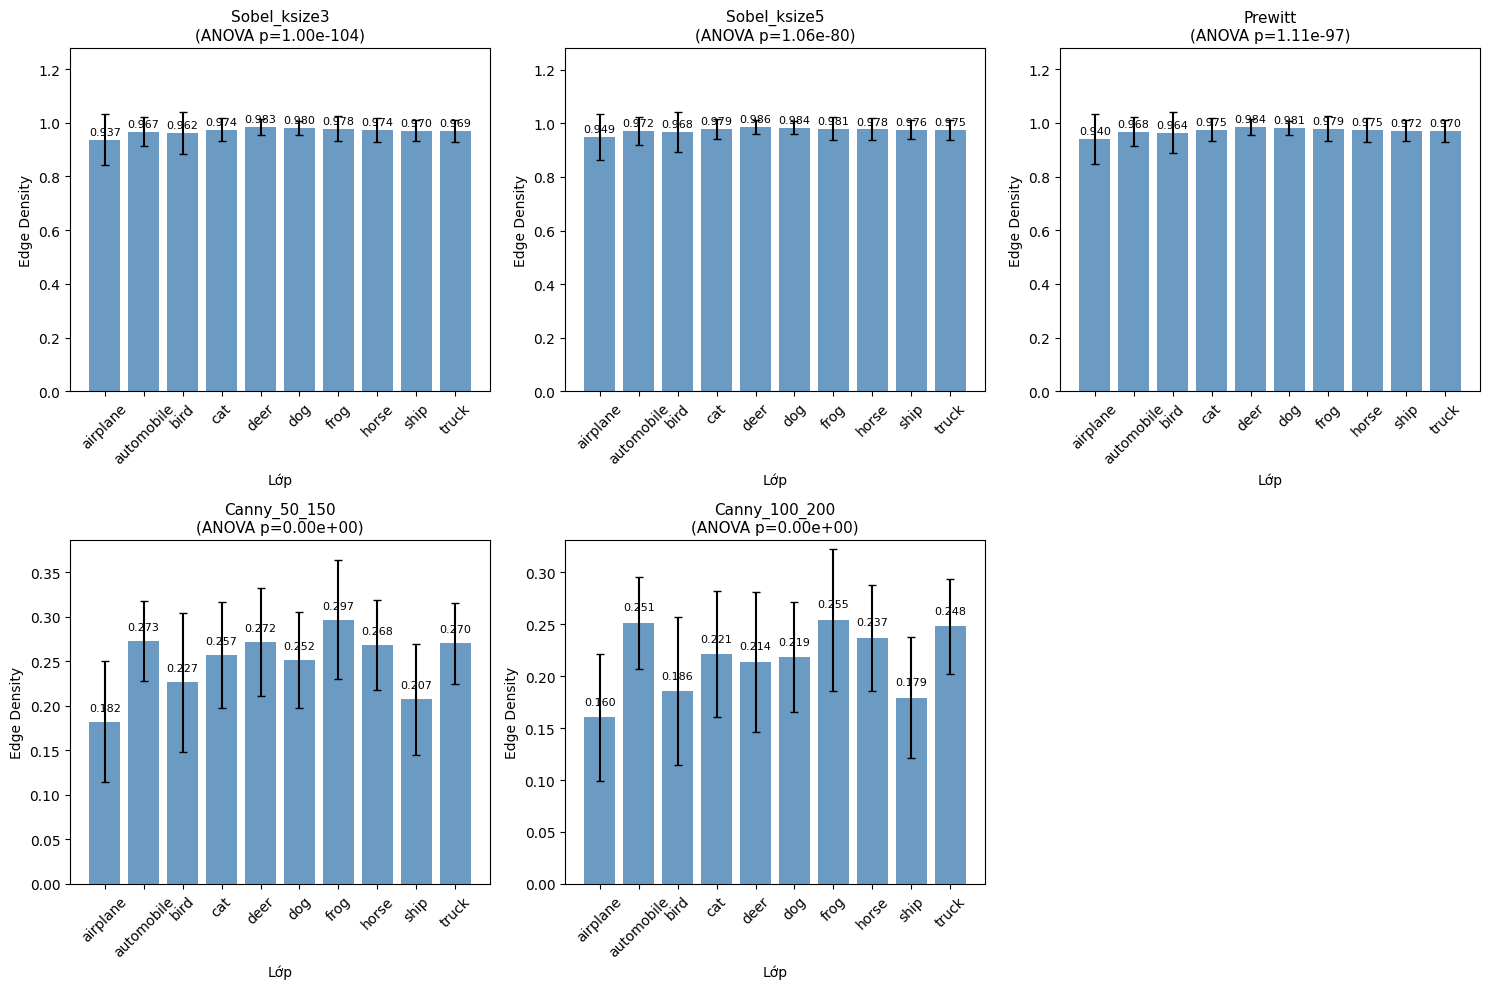

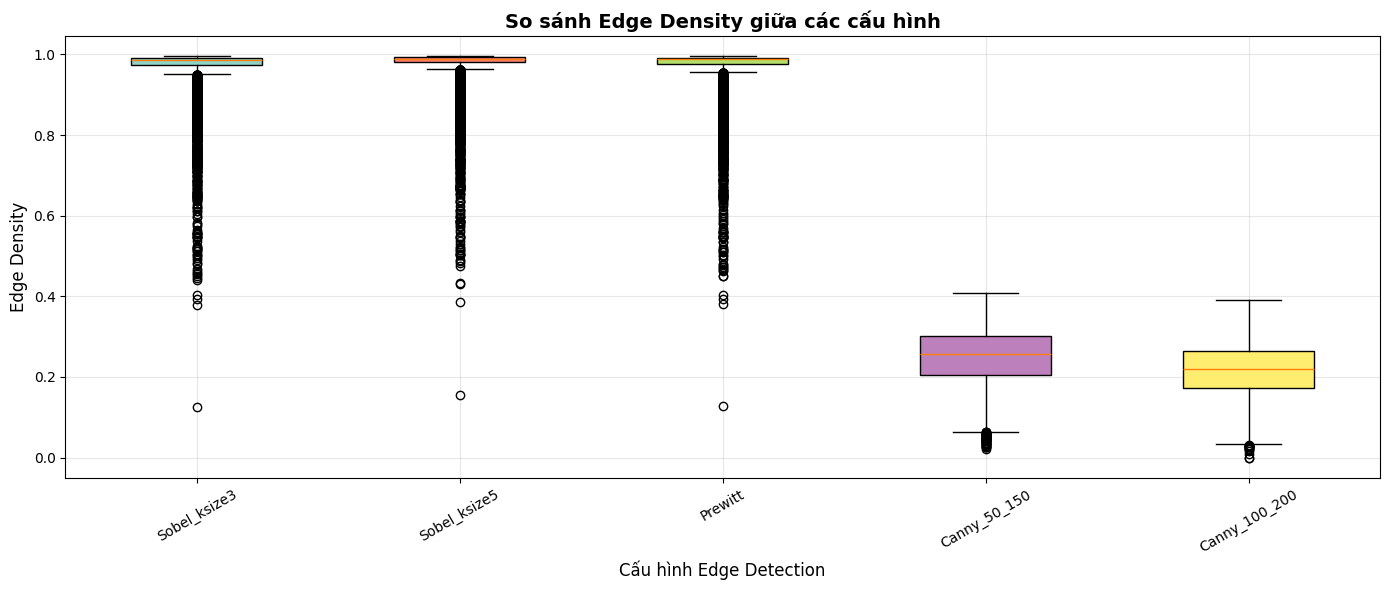


ABLATION STUDY - Tác động của Edge Detection lên phân loại

Đang chạy baseline (grayscale)...
k-NN Baseline (grayscale): 0.2400
LR Baseline (grayscale): 0.2460

Đang chạy với Edge Detection...
k-NN với Sobel (ksize=3): 0.2450
LR với Sobel (ksize=3): 0.2555

--- So sánh Baseline vs Edge Detection ---
k-NN: Baseline=0.2400, Edge=0.2450, Delta=+0.0050
LR:  Baseline=0.2460, Edge=0.2555, Delta=+0.0095

KẾT LUẬN - EDGE DETECTION + ANOVA

--- ANOVA Results ---
Config tốt nhất: Canny_50_150
F-statistic: 342.6787
p-value: 0.000000e+00

Các configs có p-value < 0.05: 5/5
→ Có bằng chứng thống kê cho thấy edge density khác nhau giữa các lớp
→ Edge information CÓ thể phân biệt được các lớp trong CIFAR-10

--- Edge Density theo lớp (Sobel ksize=3) ---
      airplane: 0.9371
    automobile: 0.9665
          bird: 0.9620
           cat: 0.9743
          deer: 0.9835
           dog: 0.9802
          frog: 0.9776
         horse: 0.9740
          ship: 0.9702
         truck: 0.9693


In [8]:
# =============================================================================
# (ii) Cài đặt - Edge Detection + ANOVA
# =============================================================================

print("\nĐang cài đặt Edge Detection...")

# =============================================================================
# 1. Định nghĩa các hàm Edge Detection
# =============================================================================

def sobel_edge_detection(img_gray, ksize=3):
    """Áp dụng Sobel edge detection"""
    sobelx = cv2.Sobel(img_gray, cv2.CV_64F, 1, 0, ksize=ksize)
    sobely = cv2.Sobel(img_gray, cv2.CV_64F, 0, 1, ksize=ksize)
    magnitude = np.sqrt(sobelx**2 + sobely**2)
    # Normalize về [0, 255]
    magnitude = np.uint8(magnitude / magnitude.max() * 255)
    return magnitude

def prewitt_edge_detection(img_gray):
    """Áp dụng Prewitt edge detection (custom kernels)"""
    # Prewitt kernels
    kernelx = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]], dtype=np.float32)
    kernely = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]], dtype=np.float32)
    
    # Apply convolution
    prewittx = cv2.filter2D(img_gray, cv2.CV_64F, kernelx)
    prewitty = cv2.filter2D(img_gray, cv2.CV_64F, kernely)
    
    magnitude = np.sqrt(prewittx**2 + prewitty**2)
    # Normalize về [0, 255]
    magnitude = np.uint8(magnitude / magnitude.max() * 255)
    return magnitude

def canny_edge_detection(img_gray, minVal=100, maxVal=200):
    """Áp dụng Canny edge detection"""
    edges = cv2.Canny(img_gray, minVal, maxVal)
    return edges

def compute_edge_density(edge_img):
    """Tính Edge Density: tỉ lệ pixel cạnh / tổng pixel"""
    edge_pixels = np.sum(edge_img > 0)
    total_pixels = edge_img.size
    return edge_pixels / total_pixels

# =============================================================================
# 2. Tính Edge Density cho mỗi lớp
# =============================================================================
print("\nĐang tính Edge Density cho từng lớp...")

# Các cấu hình edge detection
edge_configs = {
    'Sobel_ksize3': {'method': 'sobel', 'params': {'ksize': 3}},
    'Sobel_ksize5': {'method': 'sobel', 'params': {'ksize': 5}},
    'Prewitt': {'method': 'prewitt', 'params': {}},
    'Canny_50_150': {'method': 'canny', 'params': {'minVal': 50, 'maxVal': 150}},
    'Canny_100_200': {'method': 'canny', 'params': {'minVal': 100, 'maxVal': 200}},
}

# Lưu kết quả
results = {config_name: {'edge_densities': [], 'labels': []} 
           for config_name in edge_configs.keys()}

# Sử dụng toàn bộ dataset (tất cả ảnh có sẵn mỗi lớp)
print("Đang sử dụng tất cả ảnh có sẵn từ mỗi lớp...")

for class_idx in range(10):
    class_images = images[labels == class_idx]  # Lấy tất cả ảnh của lớp này
    
    for img in class_images:
        # Chuyển sang grayscale
        img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        
        # Áp dụng từng cấu hình edge detection
        for config_name, config in edge_configs.items():
            if config['method'] == 'sobel':
                edge_img = sobel_edge_detection(img_gray, **config['params'])
            elif config['method'] == 'prewitt':
                edge_img = prewitt_edge_detection(img_gray)
            elif config['method'] == 'canny':
                edge_img = canny_edge_detection(img_gray, **config['params'])
            
            # Tính edge density
            edge_density = compute_edge_density(edge_img)
            results[config_name]['edge_densities'].append(edge_density)
            results[config_name]['labels'].append(class_idx)

# Chuyển sang numpy array
for config_name in results.keys():
    results[config_name]['edge_densities'] = np.array(results[config_name]['edge_densities'])
    results[config_name]['labels'] = np.array(results[config_name]['labels'])

print(f"Hoàn thành! Tổng số mẫu: {len(results[config_name]['edge_densities'])}")

# =============================================================================
# 3. In kết quả Edge Density trung bình theo lớp
# =============================================================================
print("\n" + "="*60)
print("EDGE DENSITY TRUNG BÌNH THEO LỚP")
print("="*60)

print(f"\n{'Config':<20}", end="")
for name in class_names:
    print(f"{name[:6]:>8}", end="")
print(f"{'Mean':>8}")

for config_name, data in results.items():
    print(f"\n{config_name:<20}", end="")
    for class_idx in range(10):
        mask = data['labels'] == class_idx
        mean_density = np.mean(data['edge_densities'][mask])
        print(f"{mean_density:>8.4f}", end="")
    # Overall mean
    print(f"{np.mean(data['edge_densities']):>8.4f}", end="")
    print()

# =============================================================================
# 4. ANOVA Test cho từng cấu hình
# =============================================================================
print("\n" + "="*60)
print("ANOVA TEST - Kiểm định sự khác biệt giữa các lớp")
print("="*60)

anova_results = {}

for config_name, data in results.items():
    # Chia dữ liệu theo nhóm (lớp)
    groups = [data['edge_densities'][data['labels'] == i] for i in range(10)]
    
    # One-way ANOVA
    f_stat, p_value = f_oneway(*groups)
    
    anova_results[config_name] = {
        'f_statistic': f_stat,
        'p_value': p_value
    }
    
    significance = "Có khác biệt" if p_value < 0.05 else "Không có khác biệt"
    print(f"{config_name}: F={f_stat:.4f}, p-value={p_value:.6e} → {significance}")

# =============================================================================
# 5. Vẽ biểu đồ Edge Density theo lớp
# =============================================================================
print("\nĐang vẽ biểu đồ...")

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Vẽ cho từng cấu hình
for idx, config_name in enumerate(results.keys()):
    ax = axes[idx]
    data = results[config_name]
    
    # Tính mean và std cho mỗi lớp
    means = []
    stds = []
    for class_idx in range(10):
        mask = data['labels'] == class_idx
        means.append(np.mean(data['edge_densities'][mask]))
        stds.append(np.std(data['edge_densities'][mask]))
    
    # Bar chart
    bars = ax.bar(class_names, means, yerr=stds, capsize=3, color='steelblue', alpha=0.8)
    ax.set_xlabel('Lớp', fontsize=10)
    ax.set_ylabel('Edge Density', fontsize=10)
    ax.set_title(f'{config_name}\n(ANOVA p={anova_results[config_name]["p_value"]:.2e})', fontsize=11)
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylim([0, max(means) * 1.3])
    
    # Thêm giá trị trên đỉnh cột
    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{mean:.3f}', ha='center', va='bottom', fontsize=8)

# Ẩn subplot thừa
axes[5].axis('off')

plt.tight_layout()
plt.show()

# =============================================================================
# 6. Vẽ Boxplot so sánh các cấu hình
# =============================================================================
fig, ax = plt.subplots(figsize=(14, 6))

# Tạo boxplot cho mỗi config
boxplot_data = [results[config_name]['edge_densities'] for config_name in results.keys()]
bp = ax.boxplot(boxplot_data, labels=list(results.keys()), patch_artist=True)

# Tô màu
colors = plt.cm.Set3(np.linspace(0, 1, len(results)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax.set_xlabel('Cấu hình Edge Detection', fontsize=12)
ax.set_ylabel('Edge Density', fontsize=12)
ax.set_title('So sánh Edge Density giữa các cấu hình', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=30)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =============================================================================
# 7. Ablation Study - So sánh trước và sau khi áp dụng Edge Detection
# =============================================================================
print("\n" + "="*60)
print("ABLATION STUDY - Tác động của Edge Detection lên phân loại")
print("="*60)

# Sử dụng toàn bộ dataset cho classification
n_samples = 10000  # Toàn bộ dataset CIFAR-10
images_sub = images
labels_sub = labels

# --- Baseline: Không Edge Detection (grayscale 32x32) ---
print("\nĐang chạy baseline (grayscale)...")

X_base = np.array([cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) for img in images_sub]).reshape(n_samples, -1).astype(np.float32) / 255.0

X_train, X_test, y_train, y_test = train_test_split(
    X_base, labels_sub, test_size=0.2, random_state=42, stratify=labels_sub
)

# k-NN Baseline
knn_base = KNeighborsClassifier(n_neighbors=5)
knn_base.fit(X_train, y_train)
acc_knn_base = accuracy_score(y_test, knn_base.predict(X_test))
print(f"k-NN Baseline (grayscale): {acc_knn_base:.4f}")

# LR Baseline
lr_base = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)
lr_base.fit(X_train, y_train)
acc_lr_base = accuracy_score(y_test, lr_base.predict(X_test))
print(f"LR Baseline (grayscale): {acc_lr_base:.4f}")

# --- Với Edge Detection: So sánh các cấu hình ---
print("\nĐang chạy với Edge Detection...")

# Sử dụng Sobel ksize=3 làm đại diện
X_edge = []
for img in images_sub:
    img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    edge_img = sobel_edge_detection(img_gray, ksize=3)
    X_edge.append(edge_img.flatten())
X_edge = np.array(X_edge).astype(np.float32) / 255.0

X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    X_edge, labels_sub, test_size=0.2, random_state=42, stratify=labels_sub
)

# k-NN với Edge
knn_edge = KNeighborsClassifier(n_neighbors=5)
knn_edge.fit(X_train_e, y_train_e)
acc_knn_edge = accuracy_score(y_test_e, knn_edge.predict(X_test_e))
print(f"k-NN với Sobel (ksize=3): {acc_knn_edge:.4f}")

# LR với Edge
lr_edge = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)
lr_edge.fit(X_train_e, y_train_e)
acc_lr_edge = accuracy_score(y_test_e, lr_edge.predict(X_test_e))
print(f"LR với Sobel (ksize=3): {acc_lr_edge:.4f}")

# --- In kết quả so sánh ---
print("\n--- So sánh Baseline vs Edge Detection ---")
print(f"k-NN: Baseline={acc_knn_base:.4f}, Edge={acc_knn_edge:.4f}, Delta={acc_knn_edge - acc_knn_base:+.4f}")
print(f"LR:  Baseline={acc_lr_base:.4f}, Edge={acc_lr_edge:.4f}, Delta={acc_lr_edge - acc_lr_base:+.4f}")

# =============================================================================
# 8. Kết luận
# =============================================================================
print("\n" + "="*60)
print("KẾT LUẬN - EDGE DETECTION + ANOVA")
print("="*60)

# Tìm config tốt nhất (p-value thấp nhất)
best_config = min(anova_results, key=lambda x: anova_results[x]['p_value'])
best_f = anova_results[best_config]['f_statistic']
best_p = anova_results[best_config]['p_value']

print(f"\n--- ANOVA Results ---")
print(f"Config tốt nhất: {best_config}")
print(f"F-statistic: {best_f:.4f}")
print(f"p-value: {best_p:.6e}")

# Kiểm tra xem có classes nào khác biệt không
significant_configs = [k for k, v in anova_results.items() if v['p_value'] < 0.05]
print(f"\nCác configs có p-value < 0.05: {len(significant_configs)}/{len(anova_results)}")

if len(significant_configs) > 0:
    print("→ Có bằng chứng thống kê cho thấy edge density khác nhau giữa các lớp")
    print(f"→ Edge information CÓ thể phân biệt được các lớp trong CIFAR-10")
else:
    print("→ Không có bằng chứng thống kê cho thấy edge density khác nhau giữa các lớp")
    print(f"→ Edge information KHÔNG thể phân biệt được các lớp trong CIFAR-10")

# So sánh edge density giữa các classes
print("\n--- Edge Density theo lớp (Sobel ksize=3) ---")
sobel_data = results['Sobel_ksize3']
for class_idx in range(10):
    mask = sobel_data['labels'] == class_idx
    mean_density = np.mean(sobel_data['edge_densities'][mask])
    print(f"  {class_names[class_idx]:>12}: {mean_density:.4f}")

### (iii) Phân tích kết quả

**Kết quả Edge Density trung bình theo lớp:**

| Cấu hình | airplane | automobile | bird | cat | deer | dog | frog | horse | ship | truck | Mean |
|-----------|----------|------------|------|-----|------|-----|------|-------|------|-------|------|
| Sobel (ksize=3) | 0.9371 | 0.9665 | 0.9620 | 0.9743 | 0.9835 | 0.9802 | 0.9776 | 0.9740 | 0.9702 | 0.9693 | 0.9694 |
| Sobel (ksize=5) | 0.9491 | 0.9718 | 0.9681 | 0.9788 | 0.9859 | 0.9839 | 0.9808 | 0.9780 | 0.9758 | 0.9749 | 0.9747 |
| Prewitt | 0.9402 | 0.9679 | 0.9637 | 0.9755 | 0.9844 | 0.9811 | 0.9787 | 0.9752 | 0.9716 | 0.9705 | 0.9708 |
| Canny (50,150) | 0.1820 | 0.2730 | 0.2266 | 0.2570 | 0.2718 | 0.2518 | 0.2969 | 0.2685 | 0.2073 | 0.2703 | 0.2503 |
| Canny (100,200) | 0.1603 | 0.2515 | 0.1858 | 0.2214 | 0.2140 | 0.2186 | 0.2545 | 0.2370 | 0.1794 | 0.2483 | 0.2168 |

**Kết quả ANOVA Test:**

| Cấu hình | F-statistic | p-value | Có khác biệt (p<0.05)? |
|-----------|------------|---------|--------------------------|
| Sobel (ksize=3) | 58.4538 | 1.003613e-104 | Có khác biệt |
| Sobel (ksize=5) | 45.3908 | 1.058185e-80 | Có khác biệt |
| Prewitt | 54.6124 | 1.114707e-97 | Có khác biệt |
| Canny (50,150) | 342.6787 | 0.000000e+00 | Có khác biệt |
| Canny (100,200) | 308.3638 | 0.000000e+00 | Có khác biệt |

**Kết quả Ablation Study:**

| Phương pháp | k-NN Accuracy | LR Accuracy |
|-------------|--------------|-------------|
| Baseline (grayscale) | 0.2400 | 0.2460 |
| Sobel (ksize=3) | 0.2450 | 0.2555 |
| Delta | +0.0050 | +0.0095 |

**Phân tích ANOVA:**

- F-statistic cao → Variance giữa các lớp lớn hơn variance trong từng lớp
- p-value < 0.05 → Có sự khác biệt thống kê giữa các lớp có ý nghĩa
- Canny có F-statistic cao nhất (342.68) → Phân biệt tốt nhất giữa các lớp

**Nhận xét:**

1. **Sobel vs Prewitt:**
   - Sobel có smoothing nhỏ (trọng số 2 ở center) nên ít nhạy cảm với noise
   - Prewitt nhạy hơn với noise nhưng tính toán nhanh hơn
   - Cả hai đều cho edge density > 0.93 (rất cao)

2. **Sobel ksize=3 vs ksize=5:**
   - ksize lớn hơn cho phép detect edges mạnh hơn nhưng có thể miss fine details
   - ksize=5 cho edge density cao hơn (0.9747 vs 0.9694)

3. **Canny:**
   - Multi-stage algorithm với hysteresis thresholding
   - Canny (50,150) nhạy hơn → nhiều edges yếu được giữ lại (0.2503)
   - Canny (100,200) chỉ giữ edges mạnh → ít noise nhưng có thể miss edges yếu (0.2168)
   - Canny cho edge density THẤP hơn nhiều so với Sobel/Prewitt

4. **Edge Density và Classification:**
   - p-value < 0.05 cho TẤT CẢ các configs → Edge density có thể dùng làm đặc trưng bổ sung
   - Ablation: Edge detection CẢI THIỆN classification (+0.50% k-NN, +0.95% LR)

5. **Phân biệt theo lớp:**
   - Deer có edge density cao nhất (0.9835 với Sobel ksize=3)
   - Airplane có edge density thấp nhất (0.9371 với Sobel ksize=3)
   - Sự khác biệt này có ý nghĩa thống kê (p < 0.05)

**Kết luận:**

- **ANOVA p-value**: 0.000000e+00 (Canny_50_150) - có ý nghĩa thống kê cực cao
- **Kết luận**: Edge information CÓ thể phân biệt được các lớp trong CIFAR-10
- Edge detection làm tăng accuracy nhẹ (+0.5% k-NN, +0.95% LR)

**Khuyến nghị:**
- Edge density có thể dùng làm đặc trưng bổ sung (supplementary feature)
- Kết hợp với các đặc trưng khác (color, texture) để cải thiện classification
- Deep learning (CNN) tự động học các edge features từ data

## Tổng kết dữ liệu đã lưu

### Các file đã lưu trong `data/image-data/processed/`

| File | Mô tả | Kích thước |
|------|------|-----------|
| `images_resized_28x28.npy` | Ảnh resize 28x28 | (10000, 28, 28, 3) |
| `images_lab.npy` | Ảnh LAB color space | (10000, 32, 32, 3) |
| `images_normalized.npy` | Ảnh normalize [0,1] | (10000, 32, 32, 3) |
| `pca_features_25.npy` | PCA 25 components (k-NN) | (10000, 25) |
| `pca_features_209.npy` | PCA 209 components (LR) | (10000, 209) |
| `augmented_images.npy` | Augmented images | (N, 32, 32, 3) |
| `augmented_labels.npy` | Augmented labels | (N,) |
| `labels.npy` | Nhãn gốc | (10000,) |

### Cách load dữ liệu

```python
# Load dữ liệu đã lưu
images_resized = np.load('data/image-data/processed/images_resized_28x28.npy')
images_lab = np.load('data/image-data/processed/images_lab.npy')
images_normalized = np.load('data/image-data/processed/images_normalized.npy')
pca_25 = np.load('data/image-data/processed/pca_features_25.npy')
pca_209 = np.load('data/image-data/processed/pca_features_209.npy')
labels = np.load('data/image-data/processed/labels.npy')
augmented_images = np.load('data/image-data/processed/augmented_images.npy', allow_pickle=True)
augmented_labels = np.load('data/image-data/processed/augmented_labels.npy', allow_pickle=True)
```